# Baselines (Tier 0–1) - AIOps KPI (Event-level)


This notebook implements Tier 0–1 baselines for Case D (AIOps KPI) with **event-level detection as the primary objective**.

Key rules enforced:
- Thresholds are chosen using **validation-only event-level performance** (event precision/recall/F1).
- Point-wise metrics (Precision/Recall/F1) plus **AUROC** and **PR-AUC** are recorded as secondary diagnostics.
- Window-based features must enforce **1-minute contiguity** (exclude windows crossing gaps).
- Every run writes artefacts into a **per-run folder**, and appends a stable row into `results/all_results.csv`.


## Step 1 - Imports, paths, and global configuration


This step sets up:
- required libraries (Tier 0–1),
- project paths (using the Desktop `masters` root),
- results folders,
- and a fixed random seed for reproducibility.

No modelling happens yet.


In [156]:
#Question: Are these libraries saved as notepad notes
from __future__ import annotations

import json
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [157]:
# -----------------------------
# Project root (current machine)
# -----------------------------
PROJECT_ROOT = Path("/Users/nandipha/Desktop/masters")

# -----------------------------
# Processed data paths (Case D)
# -----------------------------
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "aiops_kpi"

TRAIN_PATH = DATA_DIR / "aiops_kpi_train.csv"
VAL_PATH   = DATA_DIR / "aiops_kpi_validation.csv"
TEST_PATH  = DATA_DIR / "aiops_kpi_test.csv"
FULL_PATH  = DATA_DIR / "aiops_kpi_full.csv"

# -----------------------------
# Results paths
# -----------------------------
RESULTS_ROOT = PROJECT_ROOT / "results"
ALL_RESULTS_PATH = RESULTS_ROOT / "all_results.csv"

RUNS_ROOT = RESULTS_ROOT / "aiops_kpi" / "baselines_event" / "runs"
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR, RESULTS_ROOT, ALL_RESULTS_PATH, RUNS_ROOT


(PosixPath('/Users/nandipha/Desktop/masters/data/processed/aiops_kpi'),
 PosixPath('/Users/nandipha/Desktop/masters/results'),
 PosixPath('/Users/nandipha/Desktop/masters/results/all_results.csv'),
 PosixPath('/Users/nandipha/Desktop/masters/results/aiops_kpi/baselines_event/runs'))

## Step 2 - Load processed splits and run basic checks


This step loads the canonical processed split files for Case D and verifies:
- required columns exist,
- time is parsed and sorted,
- there are no missing values in core columns,
- class balance (anomaly counts and proportions) per split.




In [158]:
REQUIRED_COLUMNS = [
    "time", "value", "value_scaled", "is_anomaly",
    "hour_of_day", "day_of_week", "is_weekend",
    "split", "case_study",
]

def load_split_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "time" not in df.columns:
        raise ValueError(f"`time` column missing in {path}")
    df["time"] = pd.to_datetime(df["time"], errors="raise")
    df = df.sort_values("time").reset_index(drop=True)
    return df

train_df = load_split_csv(TRAIN_PATH)
val_df   = load_split_csv(VAL_PATH)
test_df  = load_split_csv(TEST_PATH)

# quick view
train_df.head(3)


,time,value,value_scaled,is_anomaly,hour_of_day,day_of_week,is_weekend,split,case_study
0,2017-04-30 16:00:00,1.666667,-0.919925,0,16,6,1,train,aiops_kpi
1,2017-04-30 16:01:00,1.833333,-0.759141,0,16,6,1,train,aiops_kpi
2,2017-04-30 16:02:00,1.750000,-0.839533,0,16,6,1,train,aiops_kpi


In [159]:
def basic_checks(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"[{split_name}] Missing required columns: {missing_cols}")

    # core missing values
    core_cols = ["time", "value", "value_scaled", "is_anomaly", "split", "case_study"]
    missing_counts = df[core_cols].isna().sum()

    # monotonic time check
    is_sorted = df["time"].is_monotonic_increasing

    # case study check
    case_values = df["case_study"].unique()

    # class balance
    n = len(df)
    n_anom = int((df["is_anomaly"] == 1).sum())
    anom_rate = (n_anom / n) if n > 0 else np.nan

    summary = pd.DataFrame({
        "split": [split_name],
        "rows": [n],
        "anomaly_points": [n_anom],
        "anomaly_rate": [anom_rate],
        "time_sorted": [bool(is_sorted)],
        "case_study_values": [", ".join(map(str, case_values))],
    })

    missing_table = (
        missing_counts
        .rename("missing_count")
        .to_frame()
        .reset_index()
        .rename(columns={"index": "column"})
    )

    return summary, missing_table

train_summary, train_missing = basic_checks(train_df, "train")
val_summary, val_missing     = basic_checks(val_df, "validation")
test_summary, test_missing   = basic_checks(test_df, "test")

split_summary = pd.concat([train_summary, val_summary, test_summary], ignore_index=True)
split_summary


,split,rows,anomaly_points,anomaly_rate,time_sorted,case_study_values
0,train,63999,563,0.008797,True,aiops_kpi
1,validation,17268,97,0.005617,True,aiops_kpi
2,test,47768,7006,0.146667,True,aiops_kpi


In [160]:
# Missing values in core columns (should be 0s)
missing_summary = (
    pd.concat([
        train_missing.assign(split="train"),
        val_missing.assign(split="validation"),
        test_missing.assign(split="test"),
    ], ignore_index=True)
    .query("missing_count > 0")
)

missing_summary if len(missing_summary) > 0 else "No missing values in core columns."



'No missing values in core columns.'

## Step 2 - Interpretation: split integrity, anomaly concentration, and readiness for event-level evaluation

The processed AIOps KPI splits load successfully and satisfy core integrity checks:
- All three splits are time-sorted (`time_sorted = True`) and consistently labelled as `case_study = aiops_kpi`.
- No missing values are present in the core modelling columns (`time`, `value`, `value_scaled`, `is_anomaly`, `split`, `case_study`), supporting reliable scoring and metric computation.

Class balance is strongly non-stationary across splits:
- **Train:** 63,999 rows; 563 anomaly points; anomaly rate ≈ **0.88%**
- **Validation:** 17,268 rows; 97 anomaly points; anomaly rate ≈ **0.56%**
- **Test:** 47,768 rows; 7,006 anomaly points; anomaly rate ≈ **14.67%**

This confirms that the evaluation is intentionally stress-oriented: the **test split contains a dense incident regime** with substantially higher anomaly prevalence than train/validation. This is consistent with the Case D split design goal (incident regime concentrated in test) and supports drift-aware evaluation.

Implications for Tier 0–1 baselines:
- Thresholds must be selected on the **validation split only** to avoid leakage; however, validation anomalies are relatively sparse, so event-level threshold curves may be sensitive to the number and structure of validation events. This motivates careful event construction (contiguity-aware event IDs) and transparent reporting of event counts in validation and test.
- The large distribution shift in anomaly prevalence between train/validation and test reinforces the need to report **event-level metrics as headline** and **PR-AUC as a key diagnostic** under heavy imbalance and regime shift.


## Step 3 - Construct event IDs from ground-truth anomaly labels (contiguity-aware)


Event-level evaluation requires a consistent definition of anomaly events.

In this step, ground-truth events are constructed by identifying continuos runs of `is_anomaly == 1` under the dominant sampling interval (1 minute). Each anomaly run is assigned an `event_id`, enabling event-level precision/recall/F1 and detection delay calculations.


In [161]:
# Question: Logic behind event build
# ------------------------------------------------------------
# Step 3: Load the full processed dataset and build event IDs
# ------------------------------------------------------------

# Load the full dataset to ensure events are defined on the complete time axis
full_df = load_split_csv(FULL_PATH)

# Basic expectation: the full dataset should contain the same required columns
missing_cols_full = [c for c in REQUIRED_COLUMNS if c not in full_df.columns]
if missing_cols_full:
    raise ValueError(f"[full] Missing required columns: {missing_cols_full}")

# Ensure correct dtype for labels
full_df["is_anomaly"] = full_df["is_anomaly"].astype(int)

# Compute time deltas in minutes to support contiguity checks (dominant interval expected: 1 minute)
full_df["delta_minutes"] = full_df["time"].diff().dt.total_seconds().div(60)

# A new anomaly event starts when:
# - current point is anomalous, AND
# - either the previous point is not anomalous OR the time gap is not 1 minute (break in contiguity)
is_anom = full_df["is_anomaly"] == 1
prev_is_anom = full_df["is_anomaly"].shift(1, fill_value=0) == 1
gap_break = full_df["delta_minutes"].ne(1)  # True if gap != 1 minute (includes NaN on first row)

event_start = is_anom & (~prev_is_anom | gap_break)

# Assign event IDs by cumulative counting of event starts (only for anomaly points)
full_df["event_id"] = np.where(is_anom, event_start.cumsum() - 1, np.nan)

# Quick check: number of events (overall)
n_events = int(np.nanmax(full_df["event_id"]) + 1) if full_df["event_id"].notna().any() else 0
n_events


113

In [162]:
# ------------------------------------------------------------
# Build an event summary table for reporting and later evaluation
# ------------------------------------------------------------
if n_events == 0:
    event_summary = pd.DataFrame(columns=["event_id", "start_time", "end_time", "n_points", "split"])
else:
    g = full_df.dropna(subset=["event_id"]).groupby("event_id", as_index=False)

    event_summary = g.agg(
        start_time=("time", "min"),
        end_time=("time", "max"),
        n_points=("time", "size"),
    )

    # Assign split using the split of the event start timestamp
    # (This mirrors the charter’s intent to attribute events to the segment where they begin.)
    start_to_split = (
        full_df.loc[full_df["event_id"].notna(), ["event_id", "time", "split"]]
        .sort_values(["event_id", "time"])
        .groupby("event_id", as_index=False)
        .first()[["event_id", "split"]]
    )
    event_summary = event_summary.merge(start_to_split, on="event_id", how="left")

event_summary.head(10)


,event_id,start_time,end_time,n_points,split
0,0.0,2017-05-04 06:09:00,2017-05-04 06:22:00,14,train
1,1.0,2017-05-04 08:32:00,2017-05-04 08:32:00,1,train
2,2.0,2017-05-04 08:35:00,2017-05-04 08:39:00,5,train
3,3.0,2017-05-04 09:25:00,2017-05-04 09:32:00,8,train
4,4.0,2017-05-05 09:06:00,2017-05-05 09:15:00,10,train
5,5.0,2017-05-05 09:49:00,2017-05-05 09:56:00,8,train
6,6.0,2017-05-06 07:37:00,2017-05-06 07:44:00,8,train
7,7.0,2017-05-06 08:31:00,2017-05-06 08:37:00,7,train
8,8.0,2017-05-06 08:53:00,2017-05-06 09:04:00,12,train
9,9.0,2017-05-06 09:32:00,2017-05-06 09:38:00,7,train


In [163]:
# ------------------------------------------------------------
# Count events by split (validation/test counts matter for thresholding stability)
# ------------------------------------------------------------
events_by_split = (
    event_summary.groupby("split", dropna=False)
    .size()
    .rename("n_events")
    .reset_index()
    .sort_values("split")
)

events_by_split


,split,n_events
0,test,38
1,train,64
2,validation,11


## Step 3 - Interpretation: ground-truth event construction and split distribution

Ground-truth anomaly **events** were successfully constructed from the point-wise labels using a **1-minute contiguity rule**. This produces an event-level representation suitable for the headline evaluation metrics.

### Event inventory (overall)
- Total anomaly events identified in the full series: **113**
- Event durations vary substantially: the preview shows both **single-point events** (`n_points = 1`) and **multi-minute events** (e.g., 8–14 points), indicating that the label structure includes both short spikes and sustained anomaly episodes.

### Event distribution by split (important for thresholding stability)
- **Train:** 64 events  
- **Validation:** 11 events  
- **Test:** 38 events  

This distribution is consistent with the split design that reserves a substantial incident regime for final evaluation (test), while still retaining a non-trivial number of events for validation-based threshold selection.

### Implications for Tier 0–1 modelling and evaluation
- Validation contains **11 events**, which is sufficient to support **event-level threshold selection** (validation event-F1), though results may still be sensitive to the behaviour of a small number of events. This supports reporting both:
  - the selected threshold and validation event metrics, and
  - diagnostic plots showing how predicted events align with true events in validation.
- Test contains **38 events**, supporting a more stable headline comparison of baselines using **test event precision/recall/F1**.
- Because event lengths vary (including single-point events), thresholding must balance detecting short events without generating excessive false predicted events. This strengthens the rationale for reporting **event-level precision** alongside event recall, and retaining **PR-AUC** as a key point-wise diagnostic under imbalance.


## Step 4 - Define event-level and point-wise metric functions (evaluation harness)


This step defines reusable metric functions that will be applied consistently across all Tier 0–1 baselines.

Event-level metrics are the primary outputs:
- event precision, event recall, event F1
- optional median detection delay (minutes)

Point-wise metrics and score-based diagnostics are computed as supporting evidence:
- precision, recall, F1 at the chosen threshold
- AUROC and PR-AUC using continuous anomaly scores


In [164]:
# QUESTION: logic behind build of utilities
# ------------------------------------------------------------
# Step 4: Metric utilities (event-level primary, point-wise secondary)
# ------------------------------------------------------------

def build_pred_events(times: pd.Series, pred_is_anomaly: pd.Series, delta_minutes: pd.Series) -> pd.DataFrame:
    """
    Construct predicted events as contiguous runs where pred_is_anomaly == 1,
    using the same contiguity rule as ground truth (delta == 1 minute).
    Returns a table with columns: pred_event_id, start_time, end_time.
    """
    pred = pred_is_anomaly.astype(int).to_numpy()
    is_pred = pred == 1

    # A predicted event starts when current is predicted anomaly and either:
    # - previous is not predicted anomaly, or
    # - contiguity breaks (gap != 1 minute)
    prev_is_pred = np.concatenate([[False], is_pred[:-1]])
    gap_break = delta_minutes.ne(1).to_numpy()

    pred_start = is_pred & (~prev_is_pred | gap_break)

    # Assign IDs for predicted anomaly points only
    pred_event_id = np.where(is_pred, pred_start.cumsum() - 1, np.nan)

    if np.all(np.isnan(pred_event_id)):
        return pd.DataFrame(columns=["pred_event_id", "start_time", "end_time"])

    tmp = pd.DataFrame({
        "time": times.to_numpy(),
        "pred_event_id": pred_event_id,
    }).dropna(subset=["pred_event_id"])

    out = (
        tmp.groupby("pred_event_id", as_index=False)
        .agg(start_time=("time", "min"), end_time=("time", "max"))
    )
    return out


def event_overlap(a_start: pd.Timestamp, a_end: pd.Timestamp, b_start: pd.Timestamp, b_end: pd.Timestamp) -> bool:
    """Return True if [a_start, a_end] overlaps [b_start, b_end]."""
    return (a_start <= b_end) and (b_start <= a_end)


def compute_event_metrics(
    true_events: pd.DataFrame,
    pred_events: pd.DataFrame,
) -> Dict[str, float]:
    """
    Compute event precision/recall/F1 using overlap-based matching:
    - A true event is detected if it overlaps any predicted event.
    - A predicted event is correct if it overlaps any true event.
    """
    if len(true_events) == 0:
        return {"event_precision": np.nan, "event_recall": np.nan, "event_f1": np.nan}

    # True events detected
    true_detected = 0
    for _, te in true_events.iterrows():
        hit = any(
            event_overlap(te["start_time"], te["end_time"], pe["start_time"], pe["end_time"])
            for _, pe in pred_events.iterrows()
        )
        true_detected += int(hit)

    # Predicted events correct
    pred_correct = 0
    for _, pe in pred_events.iterrows():
        hit = any(
            event_overlap(pe["start_time"], pe["end_time"], te["start_time"], te["end_time"])
            for _, te in true_events.iterrows()
        )
        pred_correct += int(hit)

    event_recall = true_detected / len(true_events) if len(true_events) > 0 else np.nan
    event_precision = pred_correct / len(pred_events) if len(pred_events) > 0 else 0.0

    if event_precision + event_recall == 0:
        event_f1 = 0.0
    else:
        event_f1 = 2 * (event_precision * event_recall) / (event_precision + event_recall)

    return {"event_precision": event_precision, "event_recall": event_recall, "event_f1": event_f1}


def compute_detection_delay_minutes(
    true_events: pd.DataFrame,
    times: pd.Series,
    pred_is_anomaly: pd.Series,
) -> float:
    """
    Compute median detection delay in minutes:
    For each true event, find the first predicted anomaly time within the event interval.
    Delay = first_detection_time - event_start_time.
    Returns median delay across detected events. NaN if none detected.
    """
    delays = []
    pred_times = times[pred_is_anomaly.astype(bool)].to_numpy()

    for _, te in true_events.iterrows():
        # Select predicted times that fall within the true event interval
        in_event = pred_times[(pred_times >= te["start_time"]) & (pred_times <= te["end_time"])]
        if len(in_event) > 0:
            first_hit = pd.Timestamp(in_event.min())
            delay_min = (first_hit - te["start_time"]).total_seconds() / 60.0
            delays.append(delay_min)

    return float(np.median(delays)) if len(delays) > 0 else np.nan


def compute_pointwise_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Compute point-wise precision/recall/F1 at a fixed threshold."""
    return {
        "point_precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "point_recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "point_f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }


def compute_score_diagnostics(y_true: np.ndarray, scores: np.ndarray) -> Dict[str, float]:
    """
    Compute AUROC and PR-AUC from continuous scores.
    Returns NaN if only one class is present in y_true (cannot compute AUC).
    """
    y_true = y_true.astype(int)

    if len(np.unique(y_true)) < 2:
        return {"auroc": np.nan, "pr_auc": np.nan}

    return {
        "auroc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
    }


In [165]:
# ------------------------------------------------------------
# Prepare true-event tables for validation and test (from event_summary)
# ------------------------------------------------------------
true_events_val = event_summary[event_summary["split"] == "validation"][["event_id", "start_time", "end_time"]].copy()
true_events_test = event_summary[event_summary["split"] == "test"][["event_id", "start_time", "end_time"]].copy()

len(true_events_val), len(true_events_test)


(11, 38)

## Step 4 - Interpretation: event tables ready for evaluation

Split-specific ground-truth event tables were constructed successfully:
- **Validation true events:** 11
- **Test true events:** 38

This confirms that the evaluation harness has sufficient event coverage to:
- perform **validation-only event-level threshold selection** (based on 11 events), and
- report **headline test event-level metrics** on a larger event set (38 events), supporting more stable comparisons between Tier 0 and Tier 1 baselines.

These event tables will be used consistently for all subsequent baselines to compute:
- event precision, event recall, event F1 (primary), and
- optional detection delay summaries.


## Step 5 - Define run logging and artefact saving utilities


This step defines a consistent logging and saving protocol used by every Tier 0–1 baseline run.

A new `all_results.csv` is created with a fixed, portable schema:
- identifiers and modelling choices,
- threshold strategy and value,
- event-level validation and test metrics (headline),
- point-wise diagnostics on test (supporting),
- runtime summaries,
- auto-generated notes.


In [166]:
# ------------------------------------------------------------
# Step 5: Run logging and artefact saving utilities
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import numpy as np

# Project root (local directory containing the research repository/files)
PROJECT_ROOT = Path("/Users/nandipha/Desktop/masters")

# Results paths
RESULTS_ROOT = PROJECT_ROOT / "results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

ALL_RESULTS_PATH = RESULTS_ROOT / "all_results.csv"

# Locked: performance-only schema (portable across machines)
ALL_RESULTS_COLUMNS = [
    # identifiers
    "run_id", "run_timestamp", "case_study", "tier", "model_name",

    # input/feature contract (portable descriptors)
    "window_length_L", "feature_mode", "uses_time_features", "contiguity_enforced", "score_definition",

    # thresholding
    "threshold_strategy", "threshold_value",

    # validation headline (event-level)
    "val_event_precision", "val_event_recall", "val_event_f1", "val_event_delay_median_minutes",

    # test headline (event-level)
    "test_event_precision", "test_event_recall", "test_event_f1", "test_event_delay_median_minutes",

    # test point-wise diagnostics
    "test_point_precision", "test_point_recall", "test_point_f1", "test_auroc", "test_pr_auc",

    # runtime
    "train_seconds", "score_seconds",

    # notes
    "notes",
]

# Create a clean file from scratch (assumes any previous file was intentionally deleted)
pd.DataFrame(columns=ALL_RESULTS_COLUMNS).to_csv(ALL_RESULTS_PATH, index=False)

ALL_RESULTS_PATH



PosixPath('/Users/nandipha/Desktop/masters/results/all_results.csv')

## Step 5 - Interpretation: master results logging initialised

The master results file path is correctly set to:

- `.../masters/results/all_results.csv`

The logging scaffold is now ready to:
- create per-run folders under `results/aiops_kpi/baselines_event/runs/<run_id>/`, and
- append stable, comparable run summaries into `all_results.csv` without introducing model-specific columns.

This supports reproducible experiment tracking across Tier 0–3 while keeping `all_results.csv` schema stable and audit-friendly.


## Step 5.1 - Auto-generate run notes (rule-based tags)


The master table includes a compact `notes` field to summarise model behaviour.

Notes are generated automatically using simple, interpretable rules that flag:
- conservative thresholding (high precision, low recall),
- strong validation-to-test degradation (possible calibration shift),
- mismatch between high PR-AUC and low event recall.


In [188]:
# ------------------------------------------------------------
# Step 5.1: Auto-notes rules (simple, interpretable)
# ------------------------------------------------------------

def auto_notes(
    val_event_precision: float,
    val_event_recall: float,
    val_event_f1: float,
    test_event_precision: float,
    test_event_recall: float,
    test_event_f1: float,
    test_pr_auc: float,
    threshold_strategy: str,
) -> str:
    """
    Create compact tags that summarise behaviour across validation and test.
    Notes are designed to be stable and human-readable for later analysis.
    """
    tags = []

    # Conservative behaviour markers
    if (test_event_precision >= 0.95) and (test_event_recall <= 0.10):
        tags.append("conservative_threshold_test")

    if (val_event_precision >= 0.95) and (val_event_recall <= 0.70):
        tags.append("conservative_threshold_val")

    # Possible calibration / regime shift marker (validation-to-test drop)
    if (val_event_f1 - test_event_f1) >= 0.30:
        tags.append("val_to_test_drop_calibration_shift_suspected")

    # High ranking signal but poor event detection
    if (test_pr_auc >= 0.90) and (test_event_recall <= 0.10):
        tags.append("high_pr_auc_low_event_recall_mismatch")

    # Threshold strategy trace
    tags.append(f"threshold={threshold_strategy}")

    return ";".join(tags)


## Step 6 - Experiment registry (run_key + overwrite-only runs + performance-only all_results.csv)


This step establishes a clean experiment registry to prevent duplicate run folders and duplicate rows in the master
results table when rerunning cells during refactors.

Key design choices:
- A deterministic `run_key` uniquely identifies an experiment configuration that can change model performance.
- Run folders are overwrite-only and keyed by `run_key` (no timestamp in folder name).
- A lightweight `run_id` timestamp is still recorded inside `config.json` for traceability.
- `all_results.csv` is performance-only (no artefact pointers) and is updated via an UPSERT rule:
  - if `run_key` exists, overwrite that row
  - otherwise append a new row

This ensures refactoring plots or notebook presentation does not create duplicate rows or folders, while genuine
experiment changes create new `run_key` values and new rows.


In [189]:
# ------------------------------------------------------------
# Step 6: Experiment registry (run_key + overwrite-only runs)
# ------------------------------------------------------------

from __future__ import annotations

import json
import time
import warnings
from pathlib import Path
from typing import Dict, Any, List

import numpy as np
import pandas as pd

# -----------------------------
# 6.1 Global project paths
# -----------------------------
MASTERS_ROOT = Path.home() / "Desktop" / "masters"

# Results live here (clean registry)
RESULTS_ROOT = MASTERS_ROOT / "results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

# Performance-only master results table (no artefact pointers)
ALL_RESULTS_PATH = RESULTS_ROOT / "all_results.csv"

# Case-specific run root for this notebook
CASE_STUDY = "aiops_kpi"
NOTEBOOK_RUNS_ROOT = RESULTS_ROOT / CASE_STUDY / "baselines_event" / "runs"
NOTEBOOK_RUNS_ROOT.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# -----------------------------
# 6.2 Helpers: safe IO
# -----------------------------
def save_json(obj: Dict[str, Any], path: Path) -> None:
    """Save a dict to JSON with stable formatting."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, sort_keys=True, default=str)

def save_df(df: pd.DataFrame, path: Path) -> None:
    """Save a dataframe as CSV (index disabled)."""
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def load_all_results_or_empty() -> pd.DataFrame:
    """Load all_results.csv if present; otherwise return an empty dataframe."""
    if ALL_RESULTS_PATH.exists():
        return pd.read_csv(ALL_RESULTS_PATH)
    return pd.DataFrame()

# -----------------------------
# 6.3 run_key design (performance-affecting only)
# -----------------------------
def make_run_key(
    case_study: str,
    tier: int,
    model_name: str,
    window_length_L: int,
    feature_mode: str,
    uses_time_features: int,
    contiguity_enforced: int,
    score_definition_key: str,
    threshold_strategy: str,
) -> str:
    """
    Deterministic identifier for an experiment configuration.

    IMPORTANT:
    - Include ONLY choices that can change scores/metrics.
    - Exclude plotting, figure styling, narrative markdown, etc.
    """
    parts = [
        f"case={case_study}",
        f"tier={tier}",
        f"model={model_name}",
        f"L={window_length_L}",
        f"feat={feature_mode}",
        f"timefeat={uses_time_features}",
        f"contig={contiguity_enforced}",
        f"score={score_definition_key}",
        f"thr={threshold_strategy}",
    ]
    return "|".join(parts)

import hashlib
import re
from pathlib import Path

import hashlib
import re
from pathlib import Path

def run_dir_from_key(
    run_key: str,
    case_study: str,
    tier: int,
    model_slug: str,
    runs_root: Path | None = None,
    hash_len: int = 10,
) -> Path:
    """
    Overwrite-only run folder based on a stable short key.

    Folder name format:
      <case>__t<tier>__<model_slug>__rk-<shorthash>

    - shorthash is a stable hash of run_key (portable across machines)
    - details remain in config.json / notes (not the folder name)
    """
    if runs_root is None:
        runs_root = NOTEBOOK_RUNS_ROOT

    shorthash = hashlib.sha1(run_key.encode("utf-8")).hexdigest()[:hash_len]

    case = re.sub(r"[^a-z0-9]+", "_", case_study.strip().lower()).strip("_")
    slug = re.sub(r"[^a-z0-9]+", "_", model_slug.strip().lower()).strip("_")

    folder = f"{case}__t{int(tier)}__{slug}__rk-{shorthash}"

    run_dir = runs_root / folder
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir



def make_run_id_timestamp() -> str:
    """Lightweight trace id recorded in config.json (not used for folder naming)."""
    return pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

# -----------------------------
# 6.4 UPSERT results (overwrite if same run_key)
# -----------------------------
def upsert_all_results_row(row: Dict[str, Any]) -> None:
    """
    Insert or update the performance-only master results table by run_key.
    """
    if "run_key" not in row:
        raise ValueError("Row must include 'run_key'.")

    df = load_all_results_or_empty()

    # Ensure consistent columns
    incoming = pd.DataFrame([row])
    if df.empty:
        out = incoming.copy()
        save_df(out, ALL_RESULTS_PATH)
        return

    # Add any missing columns (both directions) to avoid concat warnings
    for col in incoming.columns:
        if col not in df.columns:
            df[col] = np.nan
    for col in df.columns:
        if col not in incoming.columns:
            incoming[col] = np.nan

    # Align column order
    incoming = incoming[df.columns]

    # UPSERT by run_key
    mask = df["run_key"].astype(str) == str(row["run_key"])
    if mask.any():
        df.loc[mask, :] = incoming.iloc[0].to_numpy()
        out = df
    else:
        out = pd.concat([df, incoming], ignore_index=True)

    save_df(out, ALL_RESULTS_PATH)

# -----------------------------
# 6.5 Auto-notes rule (never blank)
# -----------------------------
#deleted, Reference step 5.1 



# -----------------------------
# 6.6 Define the performance-only schema (stable columns)
# -----------------------------
PERF_COLUMNS = [
    "run_key",
    "run_id",
    "run_timestamp",

    "case_study",
    "tier",
    "model_name",

    "window_length_L",
    "feature_mode",
    "uses_time_features",
    "contiguity_enforced",
    "score_definition",

    "threshold_strategy",
    "threshold_value",

    # Validation (primary + delay)
    "val_event_precision",
    "val_event_recall",
    "val_event_f1",
    "val_event_delay_median_minutes",

    # Test (primary + delay)
    "test_event_precision",
    "test_event_recall",
    "test_event_f1",
    "test_event_delay_median_minutes",

    # Test (secondary point-wise + ranking)
    "test_point_precision",
    "test_point_recall",
    "test_point_f1",
    "test_auroc",
    "test_pr_auc",

    # Runtime
    "train_seconds",
    "score_seconds",

    # Notes
    "notes",
]

# -----------------------------
# 6.7 Evaluation utilities (event metrics + threshold selection)
# -----------------------------

from __future__ import annotations
from typing import Tuple, Dict, Any

import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
)

def _contiguous_runs(mask: np.ndarray) -> np.ndarray:
    """
    Convert a 0/1 mask into run IDs for contiguous 1 segments.
    Returns an array of same length with -1 for 0s and run_id >= 0 for 1 segments.
    """
    run_ids = np.full(mask.shape[0], -1, dtype=int)
    run = -1
    for i, v in enumerate(mask):
        if v == 1 and (i == 0 or mask[i - 1] == 0):
            run += 1
        if v == 1:
            run_ids[i] = run
    return run_ids

# --- Bugfix patch: make predicted-flag handling robust (pandas OR numpy) ---

def build_predicted_events_from_flags(
    df_split: pd.DataFrame,
    pred_is_anomaly: np.ndarray | pd.Series,
) -> pd.DataFrame:
    """
    Build predicted event table from point-wise predicted flags.

    Output columns:
    - pred_event_id, start_time, end_time, n_points
    """
    if len(df_split) != len(pred_is_anomaly):
        raise ValueError("df_split and pred_is_anomaly must align in length.")

    # Robust conversion (works for pandas Series or numpy array)
    mask = np.asarray(pred_is_anomaly, dtype=int)

    run_ids = _contiguous_runs(mask)

    if (run_ids >= 0).sum() == 0:
        return pd.DataFrame(columns=["pred_event_id", "start_time", "end_time", "n_points"])

    times = pd.to_datetime(df_split["time"]).to_numpy()

    rows = []
    for rid in np.unique(run_ids[run_ids >= 0]):
        idx = np.where(run_ids == rid)[0]
        rows.append(
            {
                "pred_event_id": int(rid),
                "start_time": times[idx[0]],
                "end_time": times[idx[-1]],
                "n_points": int(len(idx)),
            }
        )

    return pd.DataFrame(rows)

def compute_event_metrics(
    true_events_split: pd.DataFrame,
    pred_events_split: pd.DataFrame,
) -> Dict[str, float]:
    """
    Event matching rule:
    - A true event is detected if ANY predicted event overlaps it.
    - A predicted event is false if it overlaps no true event.
    """
    n_true = int(len(true_events_split))
    n_pred = int(len(pred_events_split))

    if n_true == 0 and n_pred == 0:
        return {"event_precision": 1.0, "event_recall": 1.0, "event_f1": 1.0}

    if n_true == 0:
        return {"event_precision": 0.0, "event_recall": 1.0, "event_f1": 0.0}

    if n_pred == 0:
        return {"event_precision": 1.0, "event_recall": 0.0, "event_f1": 0.0}

    # Overlap check
    detected_true = 0
    for _, te in true_events_split.iterrows():
        te_s, te_e = te["start_time"], te["end_time"]
        overlaps = ((pred_events_split["start_time"] <= te_e) & (pred_events_split["end_time"] >= te_s)).any()
        if overlaps:
            detected_true += 1

    matched_pred = 0
    for _, pe in pred_events_split.iterrows():
        pe_s, pe_e = pe["start_time"], pe["end_time"]
        overlaps = ((true_events_split["start_time"] <= pe_e) & (true_events_split["end_time"] >= pe_s)).any()
        if overlaps:
            matched_pred += 1

    event_recall = detected_true / n_true if n_true > 0 else 0.0
    event_precision = matched_pred / n_pred if n_pred > 0 else 0.0
    if event_precision + event_recall == 0:
        event_f1 = 0.0
    else:
        event_f1 = 2 * event_precision * event_recall / (event_precision + event_recall)

    return {
        "event_precision": float(event_precision),
        "event_recall": float(event_recall),
        "event_f1": float(event_f1),
    }

def compute_detection_delay_median_minutes(
    df_split: pd.DataFrame,
    pred_is_anomaly: np.ndarray | pd.Series,
    true_events_split: pd.DataFrame,
) -> float:
    """
    Delay per detected true event = (first predicted anomaly time within event) - (event start).
    Returns median delay in minutes over detected events. If none detected, returns NaN.
    """
    if len(true_events_split) == 0:
        return float("nan")

    times = pd.to_datetime(df_split["time"]).to_numpy()

    # Robust conversion (works for pandas Series or numpy array)
    pred_mask = (np.asarray(pred_is_anomaly, dtype=int) == 1)

    delays = []
    for _, ev in true_events_split.iterrows():
        ev_s, ev_e = ev["start_time"], ev["end_time"]

        within = (times >= np.datetime64(ev_s)) & (times <= np.datetime64(ev_e))
        hit_idx = np.where(within & pred_mask)[0]

        if len(hit_idx) > 0:
            first_hit_time = times[hit_idx[0]]
            delay_minutes = (first_hit_time - np.datetime64(ev_s)) / np.timedelta64(1, "m")
            delays.append(float(delay_minutes))

    if len(delays) == 0:
        return float("nan")

    return float(np.median(delays))

def evaluate_at_threshold(
    df_split: pd.DataFrame,
    scores: np.ndarray,
    threshold: float,
    true_events_split: pd.DataFrame,
    pred_is_anomaly: np.ndarray | None = None,
) -> Dict[str, Any]:
    """
    Compute event-level + point-wise metrics at a threshold.
    AUROC/PR-AUC use continuous scores (threshold-independent).
    """
    y_true = df_split["is_anomaly"].astype(int).to_numpy()

    if pred_is_anomaly is None:
        pred_is_anomaly = (scores >= threshold).astype(int)
    else:
        pred_is_anomaly = pred_is_anomaly.astype(int)

    # Point-wise metrics at threshold
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred_is_anomaly, average="binary", zero_division=0
    )

    # Ranking metrics
    # Guard: if y_true is all one class, roc_auc_score will error
    try:
        auroc = roc_auc_score(y_true, scores)
    except ValueError:
        auroc = float("nan")
    try:
        pr_auc = average_precision_score(y_true, scores)
    except ValueError:
        pr_auc = float("nan")

    # Event-level
    pred_events = build_predicted_events_from_flags(df_split, pred_is_anomaly)
    ev = compute_event_metrics(true_events_split, pred_events)
    delay_med = compute_detection_delay_median_minutes(df_split, pred_is_anomaly, true_events_split)

    return {
        "event_precision": ev["event_precision"],
        "event_recall": ev["event_recall"],
        "event_f1": ev["event_f1"],
        "event_delay_median_minutes": delay_med,
        "point_precision": float(p),
        "point_recall": float(r),
        "point_f1": float(f1),
        "auroc": float(auroc),
        "pr_auc": float(pr_auc),
    }

def select_threshold_event_f1(
    df_split: pd.DataFrame,
    scores: np.ndarray,
    true_events_split: pd.DataFrame,
    n_grid: int = 60,
    q_min: float = 0.80,
    q_max: float = 0.999,
) -> Tuple[float, pd.DataFrame]:
    """
    Validation-only threshold selection by maximising event-level F1.
    Signature matches the way your notebook already calls this function:
      select_threshold_event_f1(val_df, val_scores, true_events_val, n_grid=60)
    """
    qs = np.linspace(q_min, q_max, n_grid)
    thr_grid = np.quantile(scores, qs)

    rows = []
    for thr in thr_grid:
        m = evaluate_at_threshold(df_split, scores, float(thr), true_events_split)
        rows.append({
            "threshold": float(thr),
            "val_event_precision": float(m["event_precision"]),
            "val_event_recall": float(m["event_recall"]),
            "val_event_f1": float(m["event_f1"]),
            "val_point_precision": float(m["point_precision"]),
            "val_point_recall": float(m["point_recall"]),
            "val_point_f1": float(m["point_f1"]),
            "val_auroc": float(m["auroc"]),
            "val_pr_auc": float(m["pr_auc"]),
            "val_event_delay_median_minutes": float(m["event_delay_median_minutes"]),
        })

    thr_table = pd.DataFrame(rows).sort_values(
        ["val_event_f1", "val_event_recall", "val_event_precision"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    best_thr = float(thr_table.loc[0, "threshold"])
    return best_thr, thr_table



def normalise_perf_row(row: Dict[str, Any]) -> Dict[str, Any]:
    """
    Ensure row matches the performance-only schema and contains no artefact pointers.
    Missing columns are added as NaN.  QUESTION: Would it be a possibility to avoid NAN in row cols in db
    """
    clean = {k: row.get(k, np.nan) for k in PERF_COLUMNS}
    return clean

# Quick check: initialise empty results file (clean start)
if not ALL_RESULTS_PATH.exists():
    save_df(pd.DataFrame(columns=PERF_COLUMNS), ALL_RESULTS_PATH)

ALL_RESULTS_PATH


PosixPath('/Users/nandipha/Desktop/masters/results/all_results.csv')

## API Guard

In [190]:
import inspect
print(inspect.signature(make_run_key))
print(inspect.signature(run_dir_from_key))


(case_study: 'str', tier: 'int', model_name: 'str', window_length_L: 'int', feature_mode: 'str', uses_time_features: 'int', contiguity_enforced: 'int', score_definition_key: 'str', threshold_strategy: 'str') -> 'str'
(run_key: 'str', case_study: 'str', tier: 'int', model_slug: 'str', runs_root: 'Path | None' = None, hash_len: 'int' = 10) -> 'Path'


## Step 7 - Tier 0 baseline: static z-score score series (|value_scaled|) with event-level thresholding


This baseline provides a transparent Tier 0 reference for Case D.

Definition:
- anomaly_score(t) = |value_scaled(t)|

Procedure:
- Compute anomaly scores for validation and test.
- Select a decision threshold using validation only by maximising event-level F1.
- Apply the selected threshold unchanged to test.
- Report event-level metrics as the primary result and point-wise AUROC/PR-AUC as supporting diagnostics.

This step uses the experiment registry introduced in Step 6:
- deterministic run_key
- overwrite-only run folder
- performance-only UPSERT into all_results.csv


12.360756109791723

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,12.360756,1.000000,0.636364,0.777778,1.000000,0.185567,0.313043,0.882733,0.689262,3.0
1,2.295756,0.324324,1.000000,0.489796,0.565217,0.670103,0.613208,0.882733,0.689262,1.0
2,2.054579,0.151899,1.000000,0.263736,0.355670,0.711340,0.474227,0.882733,0.689262,1.0
3,2.054579,0.151899,1.000000,0.263736,0.355670,0.711340,0.474227,0.882733,0.689262,1.0
4,1.813403,0.115385,1.000000,0.206897,0.218750,0.721649,0.335731,0.882733,0.689262,1.0


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,1.0,0.636364,0.777778,3.0,1.0,0.185567,0.313043,0.882733,0.689262


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,1.0,0.026316,0.051282,3.0,1.0,0.000285,0.000571,0.990738,0.986497


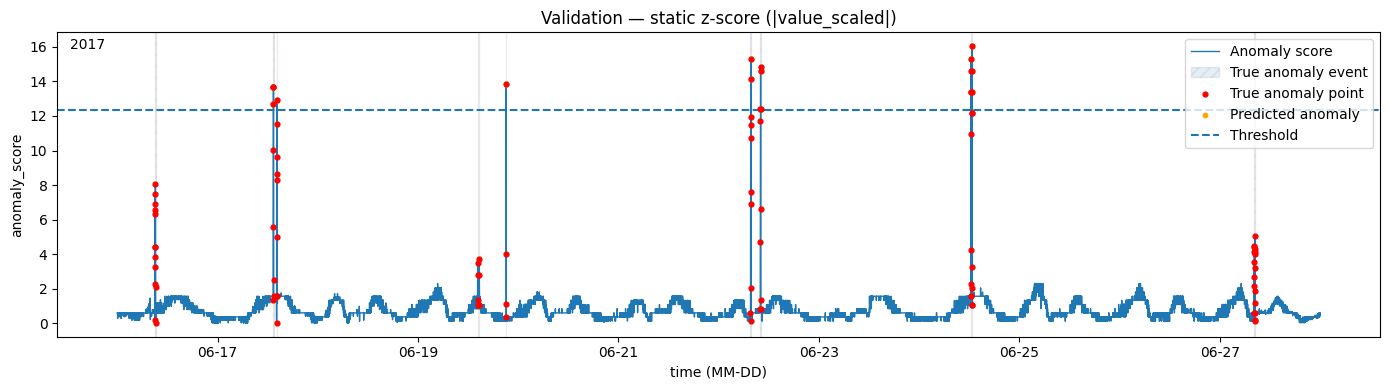

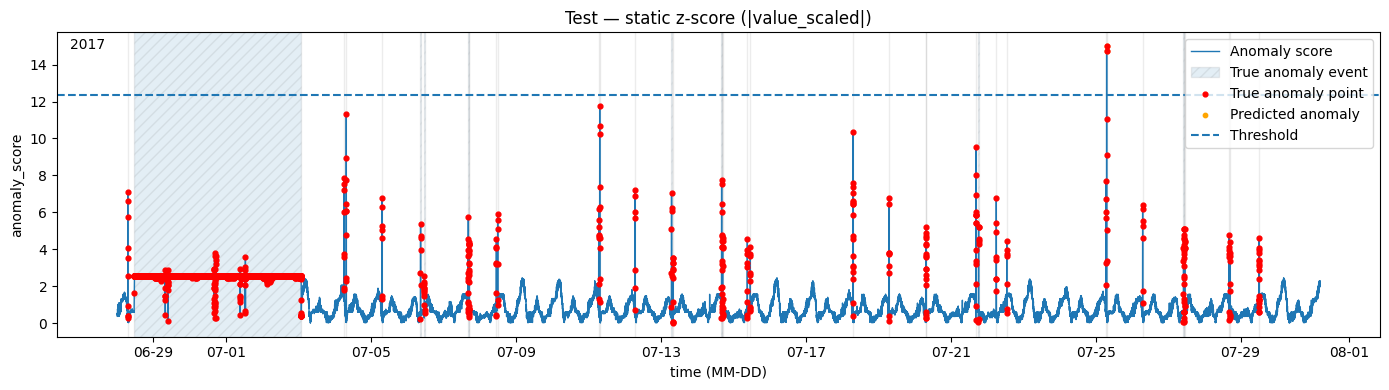

'conservative_threshold_test;conservative_threshold_val;val_to_test_drop_calibration_shift_suspected;high_pr_auc_low_event_recall_mismatch;threshold=val_event_f1'

In [192]:
# ------------------------------------------------------------
# Step 7: Tier 0 baseline — static z-score (|value_scaled|)
# ------------------------------------------------------------

import time

# -----------------------------
# 7.1 Score definition
# -----------------------------
MODEL_NAME = "heuristic_static_z_abs_value_scaled"
TIER = 0

# This string should change ONLY if the scoring meaning changes.
SCORE_DEFINITION_KEY = "abs_value_scaled"
SCORE_DEFINITION_TEXT = "abs(value_scaled) at each timestamp"

THRESHOLD_STRATEGY = "val_event_f1"

# Static z-score does not use window features
WINDOW_LENGTH_L = 0
FEATURE_MODE = "none"
USES_TIME_FEATURES = 0
CONTIGUITY_ENFORCED = 1  # event segmentation and evaluation assume 1-min contiguity for Case D

# Build deterministic run key and overwrite-only folder
run_key = make_run_key(
    case_study=CASE_STUDY,
    tier=TIER,
    model_name=MODEL_NAME,
    window_length_L=WINDOW_LENGTH_L,
    feature_mode=FEATURE_MODE,
    uses_time_features=USES_TIME_FEATURES,
    contiguity_enforced=CONTIGUITY_ENFORCED,
    score_definition_key=SCORE_DEFINITION_KEY,
    threshold_strategy=THRESHOLD_STRATEGY,
)
run_dir = run_dir_from_key(
    run_key=run_key,
    case_study=CASE_STUDY,
    tier=TIER,
    model_slug=MODEL_NAME,
)




# Trace id (recorded only in config)
run_id = make_run_id_timestamp()
run_timestamp = pd.Timestamp.now().isoformat()

# -----------------------------
# 7.2 Compute scores
# -----------------------------
t0 = time.time()

val_scores = val_df["value_scaled"].astype(float).abs().to_numpy()
test_scores = test_df["value_scaled"].astype(float).abs().to_numpy()

train_seconds = 0.0
score_seconds = time.time() - t0

# -----------------------------
# 7.3 Threshold search on validation (event-level)
# -----------------------------
best_thr, thr_table = select_threshold_event_f1(
    df_split=val_df,
    scores=val_scores,
    true_events_split=true_events_val,
    n_grid=60,
)

# -----------------------------
# 7.4 Evaluate at chosen threshold
# -----------------------------
val_metrics = evaluate_at_threshold(val_df, val_scores, best_thr, true_events_val)
test_metrics = evaluate_at_threshold(test_df, test_scores, best_thr, true_events_test)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

# Display key tables in-notebook
display(best_thr)
display(thr_table.head(5))
display(val_metrics_df)
display(test_metrics_df)

# -----------------------------
# 7.5 Predictions + plots (shown and saved)
# -----------------------------
val_pred_flags = (val_scores >= best_thr).astype(int)
test_pred_flags = (test_scores >= best_thr).astype(int)

fig_val = plot_score_timeline(
    df_split=val_df,
    scores=val_scores,
    threshold=best_thr,
    title="Validation — static z-score (|value_scaled|)",
    true_events_split=true_events_val,
    pred_is_anomaly=val_pred_flags,
)
plt.show()
fig_val.savefig(run_dir / "fig_val_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_val)

fig_test = plot_score_timeline(
    df_split=test_df,
    scores=test_scores,
    threshold=best_thr,
    title="Test — static z-score (|value_scaled|)",
    true_events_split=true_events_test,
    pred_is_anomaly=test_pred_flags,
)
plt.show()
fig_test.savefig(run_dir / "fig_test_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_test)

# -----------------------------
# 7.6 Save per-run artefacts (overwrite-only folder)
# -----------------------------
config = {
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,
    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,
    "random_seed": RANDOM_SEED,
    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,
    "threshold_strategy": THRESHOLD_STRATEGY,
}
save_json(config, run_dir / "config.json")

save_json(
    {
        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),
        "validation_best_row": thr_table.iloc[0].to_dict(),
    },
    run_dir / "threshold.json",
)

val_pred = pd.DataFrame({
    "time": val_df["time"],
    "anomaly_score": val_scores,
    "pred_is_anomaly": val_pred_flags,
    "is_anomaly": val_df["is_anomaly"].astype(int),
    "split": "validation",
    "case_study": CASE_STUDY,
})
test_pred = pd.DataFrame({
    "time": test_df["time"],
    "anomaly_score": test_scores,
    "pred_is_anomaly": test_pred_flags,
    "is_anomaly": test_df["is_anomaly"].astype(int),
    "split": "test",
    "case_study": CASE_STUDY,
})

save_df(val_pred, run_dir / "val_predictions.csv")
save_df(test_pred, run_dir / "test_predictions.csv")
save_df(val_metrics_df, run_dir / "val_metrics.csv")
save_df(test_metrics_df, run_dir / "test_metrics.csv")
save_df(thr_table, run_dir / "val_threshold_grid.csv")

# -----------------------------
# 7.7 Log performance-only results (UPSERT by run_key)
# -----------------------------
notes = auto_notes(
    val_event_precision=float(val_metrics["event_precision"]),
    val_event_recall=float(val_metrics["event_recall"]),
    val_event_f1=float(val_metrics["event_f1"]),
    test_event_precision=float(test_metrics["event_precision"]),
    test_event_recall=float(test_metrics["event_recall"]),
    test_event_f1=float(test_metrics["event_f1"]),
    test_pr_auc=float(test_metrics["pr_auc"]),
    threshold_strategy=THRESHOLD_STRATEGY,
)


row = normalise_perf_row({
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,

    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,

    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,

    "threshold_strategy": THRESHOLD_STRATEGY,
    "threshold_value": float(best_thr),

    "val_event_precision": float(val_metrics["event_precision"]),
    "val_event_recall": float(val_metrics["event_recall"]),
    "val_event_f1": float(val_metrics["event_f1"]),
    "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),

    "test_event_precision": float(test_metrics["event_precision"]),
    "test_event_recall": float(test_metrics["event_recall"]),
    "test_event_f1": float(test_metrics["event_f1"]),
    "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),

    "test_point_precision": float(test_metrics["point_precision"]),
    "test_point_recall": float(test_metrics["point_recall"]),
    "test_point_f1": float(test_metrics["point_f1"]),
    "test_auroc": float(test_metrics["auroc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),

    "train_seconds": float(train_seconds),
    "score_seconds": float(score_seconds),

    "notes": notes,
})
upsert_all_results_row(row)
notes 

# Show the updated registry row (in-notebook check)
#display(pd.DataFrame([row]))


## Step 7 - Interpretation: Tier 0 static z-score baseline (|value_scaled|)

### What was implemented
This Tier 0 baseline assigns an anomaly score to each timestamp using a magnitude-only rule:

- **anomaly_score(t) = |value_scaled(t)|**

A single decision threshold was selected on the **validation split only** using **event-level F1** as the primary objective, then applied unchanged to the test split.

---

### Threshold selection outcome (validation)
- **Chosen threshold:** **12.3608** (selected by validation event-F1)

**Validation (primary: event-level)**
- **Event precision = 1.000**
- **Event recall = 0.636**
- **Event F1 = 0.778**
- **Median detection delay = 3 minutes**

**Validation (secondary: point-wise)**
- **Point precision = 1.000**
- **Point recall = 0.186**
- **Point F1 = 0.313**
- **AUROC = 0.883**
- **PR-AUC = 0.689**

Interpretation:
- The validation-selected threshold is **high and conservative**, yielding very few predicted anomaly segments.
- This conservatism produces **perfect event precision** (no false predicted events) while still detecting a majority of validation events (event recall ≈ 0.64).
- The gap between event recall and point-wise recall is expected: the method tends to flag only the **most extreme points** within anomaly intervals rather than sustaining detection across the full duration of an event.

---

### Generalisation to test (headline results)
Applying the same validation-selected threshold to the test split yields:

**Test (primary: event-level)**
- **Event precision = 1.000**
- **Event recall = 0.026**
- **Event F1 = 0.051**
- **Median detection delay = 3 minutes**

**Test (secondary: point-wise)**
- **Point precision = 1.000**
- **Point recall = 0.000285**
- **Point F1 = 0.000571**
- **AUROC = 0.991**
- **PR-AUC = 0.986**

Interpretation:
- Test event recall collapses (~2.6%), meaning the baseline detects **almost none** of the test events under the validation-derived threshold.
- Event precision remains perfect because the baseline triggers extremely rarely; the few triggers that occur overlap true anomalies.
- The combination of **very high AUROC/PR-AUC** with **very low event recall** indicates that the score provides strong *ranking* of anomalous points, but the chosen threshold is far too conservative for the test regime. In other words, discrimination exists, but calibration/threshold transfer fails.

---

### Plot-based interpretation (validation vs test)
**Validation**
- A small number of peaks exceed the threshold and align with labelled anomaly points/events.
- This matches the validation profile: high precision with moderate recall.

**Test**
- The incident-heavy test period contains many labelled anomaly points/events, yet only a tiny fraction exceed the validation-selected threshold.
- The dominant test anomaly structure appears to involve **broader, more frequent deviations** that are not as extreme in |value_scaled| as the validation peaks that drove threshold selection.

This is consistent with the run notes:
- conservative thresholding yields high precision but suppresses recall,
- validation-to-test degradation suggests a calibration shift,
- strong PR-AUC can coexist with weak event detection when thresholding is misaligned with the incident regime.

---

### Tie back to the research objectives and Case D role
**Event-level objective (primary):**
- This run illustrates why event-level evaluation is required: despite excellent point-wise ranking (high AUROC/PR-AUC), the baseline fails to detect incidents reliably in the test regime (very low event recall). Event metrics therefore provide the more decision-relevant signal for operational anomaly detection.

**Drift/incident stress test (Case D):**
- Case D was designed so that the test split contains a dense incident regime. The strong validation-to-test performance collapse indicates the magnitude-only baseline is not robust to regime differences. This aligns with the dissertation’s drift-aware framing: evaluation must explicitly test whether methods remain reliable under changing operational conditions.

**Efficiency anchor under constraints:**
- The baseline is computationally trivial and reproducible, satisfying feasibility constraints. Its value is not in performance but in providing a transparent reference point that clarifies what additional modelling capacity must improve.

---

### Practical takeaway for Tier 0 → Tier 1 progression
- The static magnitude baseline acts as a “conservative alarm” reference: it can be tuned to avoid false positives, but it may miss the majority of incidents when regime conditions shift.
- The next Tier 0 baselines should aim to improve recall under drift while remaining leakage-safe (e.g., moving statistics that adapt to local behaviour).
- Tier 1 window-feature models (Isolation Forest, OC-SVM) are expected to improve incident detection by incorporating **window context** rather than relying on isolated extreme magnitudes, while still maintaining controlled false alarms at the event level.


## Step 8 - Tier 0 baseline: moving z-score (60-minute moving mean/std on value_scaled) with event-level thresholding


This Tier 0 baseline extends the static z-score by normalising against short-term behaviour using time-based
moving statistics.

Definition (causal, time-based):
- moving_mean(t) and moving_std(t) are computed over a 60-minute window on `value_scaled`
- z(t) = (value_scaled(t) − moving_mean(t)) / moving_std(t)
- anomaly_score(t) = |z(t)|

Leakage control:
- Validation scores use moving statistics built from training history + validation up to time t.
- Test scores use moving statistics built from training+validation history + test up to time t.

Threshold selection:
- Choose a threshold on validation by maximising event-level F1, then apply unchanged to test.


7.015874376179633

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,7.015874,0.437500,0.636364,0.518519,0.500000,0.092784,0.156522,0.789922,0.127517,1.0
1,5.208839,0.138462,0.727273,0.232633,0.236842,0.185567,0.208092,0.789922,0.127517,1.0
2,4.358899,0.104348,0.818182,0.185090,0.186567,0.257732,0.216450,0.789922,0.127517,1.0
3,3.949402,0.067901,0.818182,0.125396,0.166667,0.329897,0.221453,0.789922,0.127517,1.0
4,3.741657,0.052885,0.818182,0.099348,0.139442,0.360825,0.201149,0.789922,0.127517,1.0


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,0.4375,0.636364,0.518519,1.0,0.5,0.092784,0.156522,0.789922,0.127517


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,1.0,0.368421,0.538462,1.0,1.0,0.004853,0.009659,0.113286,0.135861


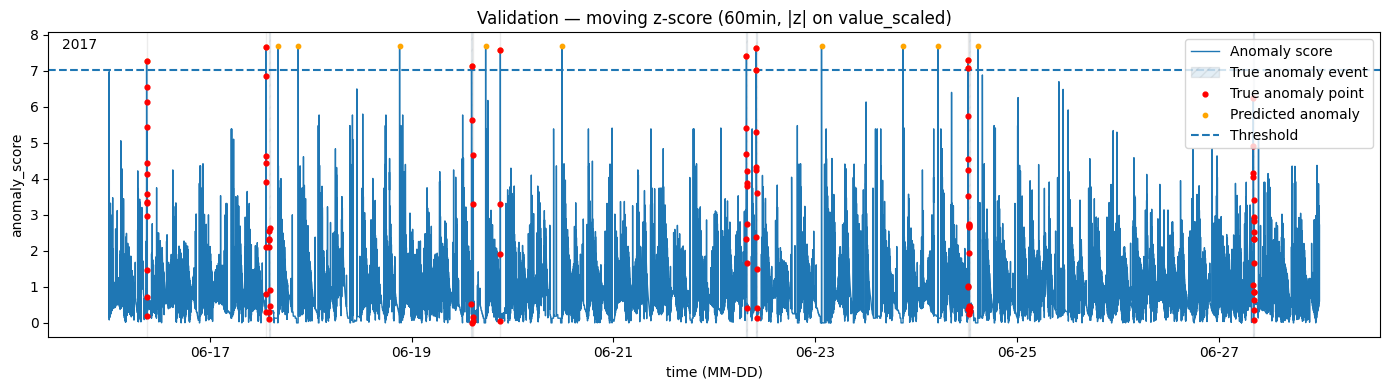

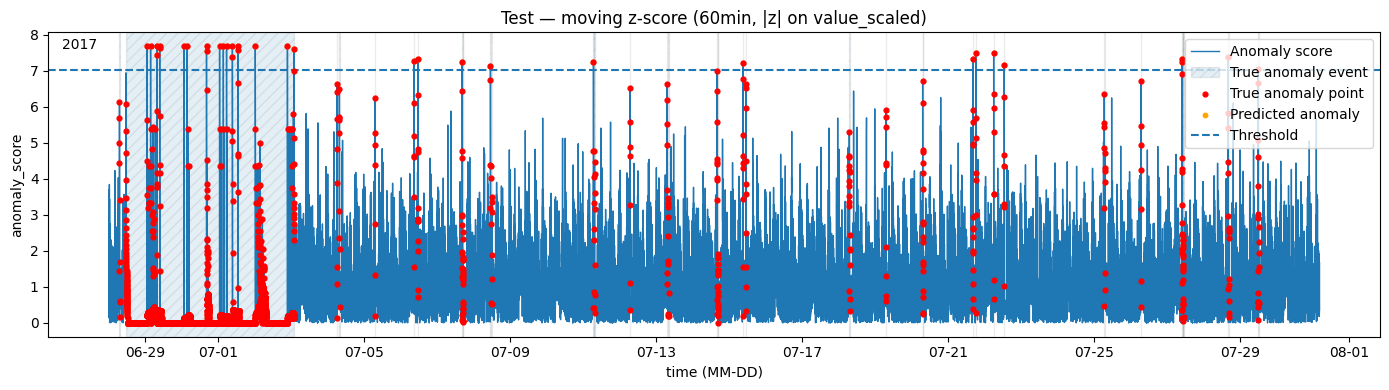

'threshold=val_event_f1'

In [193]:
# ------------------------------------------------------------
# Step 8: Tier 0 baseline — moving z-score (60min) on value_scaled
# ------------------------------------------------------------

import time

# -----------------------------
# 8.1 Moving z-score score function (causal, time-based)
# -----------------------------
def compute_causal_time_moving_z_score(
    history_df: pd.DataFrame,
    target_df: pd.DataFrame,
    window: str = "60min",
    min_periods: int = 30,
    std_epsilon: float = 1e-6,
) -> np.ndarray:
    """
    Compute a causal time-based moving z-score on value_scaled.

    Notes
    - Uses a time-based rolling window (e.g., "60min").
    - Uses history_df to warm-start the rolling statistics.
    - Returns scores aligned to target_df row order.
    - A small epsilon floors the std to avoid division-by-zero.

    Output
    - anomaly_score(t) = | (x(t) - moving_mean(t)) / max(moving_std(t), epsilon) |
    """
    combined = pd.concat([history_df, target_df], ignore_index=True).copy()
    combined = combined.sort_values("time").reset_index(drop=True)

    s = combined.set_index("time")["value_scaled"].astype(float)

    moving_mean = s.rolling(window=window, min_periods=min_periods).mean()
    moving_std = s.rolling(window=window, min_periods=min_periods).std(ddof=0)

    denom = moving_std.where(moving_std > std_epsilon, std_epsilon)
    z = (s - moving_mean) / denom
    score = z.abs()

    n_target = len(target_df)
    return score.iloc[-n_target:].to_numpy()


# -----------------------------
# 8.2 Experiment identifiers
# -----------------------------
MODEL_NAME = "heuristic_moving_z_60min_abs_value_scaled"
TIER = 0

MOVING_WINDOW = "60min"
MIN_PERIODS = 30

SCORE_DEFINITION_KEY = f"moving_z_{MOVING_WINDOW}_abs"
SCORE_DEFINITION_TEXT = f"abs((value_scaled - moving_mean_{MOVING_WINDOW}) / moving_std_{MOVING_WINDOW})"

THRESHOLD_STRATEGY = "val_event_f1"

# Static time-series score (no window feature table)
WINDOW_LENGTH_L = 0
FEATURE_MODE = "none"
USES_TIME_FEATURES = 0
CONTIGUITY_ENFORCED = 1

# Deterministic run key + overwrite-only folder
run_key = make_run_key(
    case_study=CASE_STUDY,
    tier=TIER,
    model_name=MODEL_NAME,
    window_length_L=WINDOW_LENGTH_L,
    feature_mode=FEATURE_MODE,
    uses_time_features=USES_TIME_FEATURES,
    contiguity_enforced=CONTIGUITY_ENFORCED,
    score_definition_key=SCORE_DEFINITION_KEY,
    threshold_strategy=THRESHOLD_STRATEGY,
)
run_dir = run_dir_from_key(
    run_key=run_key,
    case_study=CASE_STUDY,
    tier=TIER,
    model_slug=MODEL_NAME,
)



# Trace id (recorded only in config)
run_id = make_run_id_timestamp()
run_timestamp = pd.Timestamp.now().isoformat()

# -----------------------------
# 8.3 Compute scores (causal warm-start)
# -----------------------------
t0 = time.time()

# Validation: warm-start from train only
val_scores = compute_causal_time_moving_z_score(
    history_df=train_df[["time", "value_scaled"]].copy(),
    target_df=val_df[["time", "value_scaled"]].copy(),
    window=MOVING_WINDOW,
    min_periods=MIN_PERIODS,
)

# Test: warm-start from train + validation (past only)
test_history = pd.concat(
    [train_df[["time", "value_scaled"]], val_df[["time", "value_scaled"]]],
    ignore_index=True
)
test_scores = compute_causal_time_moving_z_score(
    history_df=test_history.copy(),
    target_df=test_df[["time", "value_scaled"]].copy(),
    window=MOVING_WINDOW,
    min_periods=MIN_PERIODS,
)

train_seconds = 0.0
score_seconds = time.time() - t0

# -----------------------------
# 8.4 Threshold search on validation (event-level)
# -----------------------------
best_thr, thr_table = select_threshold_event_f1(
    df_split=val_df,
    scores=val_scores,
    true_events_split=true_events_val,
    n_grid=60,
)

# -----------------------------
# 8.5 Evaluate at chosen threshold
# -----------------------------
val_metrics = evaluate_at_threshold(val_df, val_scores, best_thr, true_events_val)
test_metrics = evaluate_at_threshold(test_df, test_scores, best_thr, true_events_test)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

display(best_thr)
display(thr_table.head(5))
display(val_metrics_df)
display(test_metrics_df)

# -----------------------------
# 8.6 Predictions + plots (shown and saved)
# -----------------------------
val_pred_flags = (val_scores >= best_thr).astype(int)
test_pred_flags = (test_scores >= best_thr).astype(int)

fig_val = plot_score_timeline(
    df_split=val_df,
    scores=val_scores,
    threshold=best_thr,
    title="Validation — moving z-score (60min, |z| on value_scaled)",
    true_events_split=true_events_val,
    pred_is_anomaly=val_pred_flags,
)
plt.show()
fig_val.savefig(run_dir / "fig_val_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_val)

fig_test = plot_score_timeline(
    df_split=test_df,
    scores=test_scores,
    threshold=best_thr,
    title="Test — moving z-score (60min, |z| on value_scaled)",
    true_events_split=true_events_test,
    pred_is_anomaly=test_pred_flags,
)
plt.show()
fig_test.savefig(run_dir / "fig_test_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_test)

# -----------------------------
# 8.7 Save per-run artefacts (overwrite-only folder)
# -----------------------------
config = {
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,
    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,
    "random_seed": RANDOM_SEED,
    "moving_window": MOVING_WINDOW,
    "min_periods": MIN_PERIODS,
    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,
    "threshold_strategy": THRESHOLD_STRATEGY,
}
save_json(config, run_dir / "config.json")

save_json(
    {
        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),
        "validation_best_row": thr_table.iloc[0].to_dict(),
    },
    run_dir / "threshold.json",
)

val_pred = pd.DataFrame({
    "time": val_df["time"],
    "anomaly_score": val_scores,
    "pred_is_anomaly": val_pred_flags,
    "is_anomaly": val_df["is_anomaly"].astype(int),
    "split": "validation",
    "case_study": CASE_STUDY,
})
test_pred = pd.DataFrame({
    "time": test_df["time"],
    "anomaly_score": test_scores,
    "pred_is_anomaly": test_pred_flags,
    "is_anomaly": test_df["is_anomaly"].astype(int),
    "split": "test",
    "case_study": CASE_STUDY,
})

save_df(val_pred, run_dir / "val_predictions.csv")
save_df(test_pred, run_dir / "test_predictions.csv")
save_df(val_metrics_df, run_dir / "val_metrics.csv")
save_df(test_metrics_df, run_dir / "test_metrics.csv")
save_df(thr_table, run_dir / "val_threshold_grid.csv")

# -----------------------------
# 8.8 Log performance-only results (UPSERT by run_key)
# -----------------------------
notes = auto_notes(
    val_event_precision=float(val_metrics["event_precision"]),
    val_event_recall=float(val_metrics["event_recall"]),
    val_event_f1=float(val_metrics["event_f1"]),
    test_event_precision=float(test_metrics["event_precision"]),
    test_event_recall=float(test_metrics["event_recall"]),
    test_event_f1=float(test_metrics["event_f1"]),
    test_pr_auc=float(test_metrics["pr_auc"]),
    threshold_strategy=THRESHOLD_STRATEGY,
)


row = normalise_perf_row({
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,

    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,

    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,

    "threshold_strategy": THRESHOLD_STRATEGY,
    "threshold_value": float(best_thr),

    "val_event_precision": float(val_metrics["event_precision"]),
    "val_event_recall": float(val_metrics["event_recall"]),
    "val_event_f1": float(val_metrics["event_f1"]),
    "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),

    "test_event_precision": float(test_metrics["event_precision"]),
    "test_event_recall": float(test_metrics["event_recall"]),
    "test_event_f1": float(test_metrics["event_f1"]),
    "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),

    "test_point_precision": float(test_metrics["point_precision"]),
    "test_point_recall": float(test_metrics["point_recall"]),
    "test_point_f1": float(test_metrics["point_f1"]),
    "test_auroc": float(test_metrics["auroc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),

    "train_seconds": float(train_seconds),
    "score_seconds": float(score_seconds),

    "notes": notes,
})
upsert_all_results_row(row)
notes

#display(pd.DataFrame([row]))


## Step 8 - Interpretation: Tier 0 moving z-score baseline (60-minute moving window on `value_scaled`)

### What was implemented
This Tier 0 baseline scores each timestamp using a **time-based causal moving z-score** computed over a 60-minute window:

- moving_mean(t), moving_std(t) are computed using past/current values only (causal)
- **anomaly_score(t) = | (value_scaled(t) − moving_mean(t)) / moving_std(t) |**

A single decision threshold was selected on the **validation split only** by maximising **event-level F1**, then applied unchanged to the test split.

---

### Threshold selection outcome (validation)
- **Chosen threshold:** approximately **7.0159** (selected by validation event-F1)

**Validation (primary: event-level)**
- **Event precision = 0.4375**
- **Event recall = 0.6364**
- **Event F1 = 0.5185**
- **Median detection delay = 1 minute**

**Validation (secondary: point-wise)**
- **Point precision = 0.5000**
- **Point recall = 0.0928**
- **Point F1 = 0.1565**
- **AUROC ≈ 0.7899**
- **PR-AUC ≈ 0.1275**

Interpretation:
- The moving z-score baseline is less conservative than the static magnitude baseline, because local normalisation amplifies deviations relative to the recent local context.
- Validation event recall remains moderate (~0.64), but event precision is lower (~0.44), indicating that the score produces more predicted anomaly segments that do not overlap true events.
- The low PR-AUC suggests that, at the point level, many non-anomalous fluctuations are assigned relatively high scores, consistent with a high-frequency operational signal where local deviations are common.

---

### Generalisation to test (headline results)
Using the same validation-selected threshold on the test split yields:

**Test (primary: event-level)**
- **Event precision = 1.0000**
- **Event recall = 0.3684**
- **Event F1 = 0.5385**
- **Median detection delay = 1 minute**

**Test (secondary: point-wise)**
- **Point precision = 1.0000**
- **Point recall = 0.004853**
- **Point F1 = 0.009659**
- **AUROC ≈ 0.1133**
- **PR-AUC ≈ 0.1359**

Interpretation:
- Event-level performance on test improves materially relative to the static baseline: the model detects a meaningful fraction of true events (event recall ~0.37) with rapid detection (median delay 1 minute).
- Event precision is 1.0 on test, indicating that predicted event segments are sufficiently rare and positioned such that they overlap true events; this should be interpreted cautiously because event precision can appear inflated when the number of predicted events is small.
- Point-wise recall is extremely low, implying detections occur as brief spikes inside events rather than sustained detection across event duration. This aligns with the operational reading of Case D: the incident regime contains many anomalous points, but the baseline triggers only on the most locally extreme moments.
- The very low test AUROC alongside a modest PR-AUC indicates that score ranking is unstable at the point level under the test regime; however, the event-level outcome remains meaningful because event recall only requires at least one hit within each true event.

---

### Plot-based interpretation (validation vs test)
**Validation**
- The score series is highly spiky, and multiple spikes cross the threshold.
- This produces a mixture of correct detections and extra predicted segments, consistent with moderate recall and reduced precision.

**Test**
- The incident-heavy test period shows dense anomaly points/events.
- The moving z-score produces intermittent spikes above threshold that intersect some events, raising event recall compared to the static baseline.
- Predicted hits remain sparse relative to the density of anomalies, which is consistent with low point-wise recall.

---

### Tie back to the research objectives and Case D role
**Event-level objective (primary):**
- This baseline demonstrates a key methodological point: local-normalisation can improve event detection under dense incident conditions even when point-wise coverage remains weak. The event-level metrics therefore remain the correct headline measure for operational incident detection.

**Drift/incident stress test (Case D):**
- Case D places a high-anomaly incident regime in the test split by design. The improvement in test event recall relative to the static baseline suggests that adapting to local context can partially address regime differences, supporting the dissertation’s drift-aware evaluation motivation.

**Efficiency anchor under constraints:**
- The moving z-score is computationally lightweight and reproducible, providing a strong feasibility-aligned benchmark. It functions as an “adaptive heuristic” reference that Tier 1 and later deep/diffusion methods should surpass on event recall without producing excessive false alarms.

---

### Practical takeaway for Tier 0 → Tier 1 progression
- Relative to Step 7 (static |value_scaled|), this baseline is more incident-sensitive and generalises better to the incident regime at the event level, making it a stronger Tier 0 anchor.
- The persistent weakness is point-wise coverage: detections remain spike-like rather than sustained across events.
- Tier 1 window-feature models (Isolation Forest, OC-SVM) should be positioned to:
  - improve event recall by exploiting multi-point structure within windows,
  - maintain acceptable event precision via validation-based thresholding,
  - and increase point-wise separability (PR-AUC) by modelling patterns rather than isolated local deviations.


## Step 9 - Tier 0 baseline: moving median + MAD (60-minute moving window on `value_scaled`)


This step implements a robust Tier 0 baseline using a causal 60-minute moving window on `value_scaled`.

For each timestamp, the moving median and MAD are computed using past/current values only.  
The anomaly score is the absolute robust z-score:

score(t) = | value_scaled(t) − moving_median(t) | / (1.4826 × moving_MAD(t) + ε)

A validation-only threshold search maximises event-level F1 (primary objective).  
The chosen threshold is applied to the test split, and both event-level and point-wise metrics (AUROC, PR-AUC) are recorded.



4971024.471805962

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,4.971024e+06,1.000000,0.272727,0.428571,1.000000,0.185567,0.313043,0.842281,0.233534,1.0
1,7.235282e+05,0.039474,0.272727,0.068966,0.168000,0.216495,0.189189,0.842281,0.233534,1.0
2,7.235282e+05,0.032967,0.272727,0.058824,0.146853,0.216495,0.175000,0.842281,0.233534,1.0
3,4.823521e+05,0.012987,0.272727,0.024793,0.058172,0.216495,0.091703,0.842281,0.233534,1.0
4,4.823521e+05,0.012987,0.272727,0.024793,0.058172,0.216495,0.091703,0.842281,0.233534,1.0


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,1.0,0.272727,0.428571,1.0,1.0,0.185567,0.313043,0.842281,0.233534


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,1.0,0.105263,0.190476,4.5,1.0,0.003711,0.007395,0.219297,0.155849


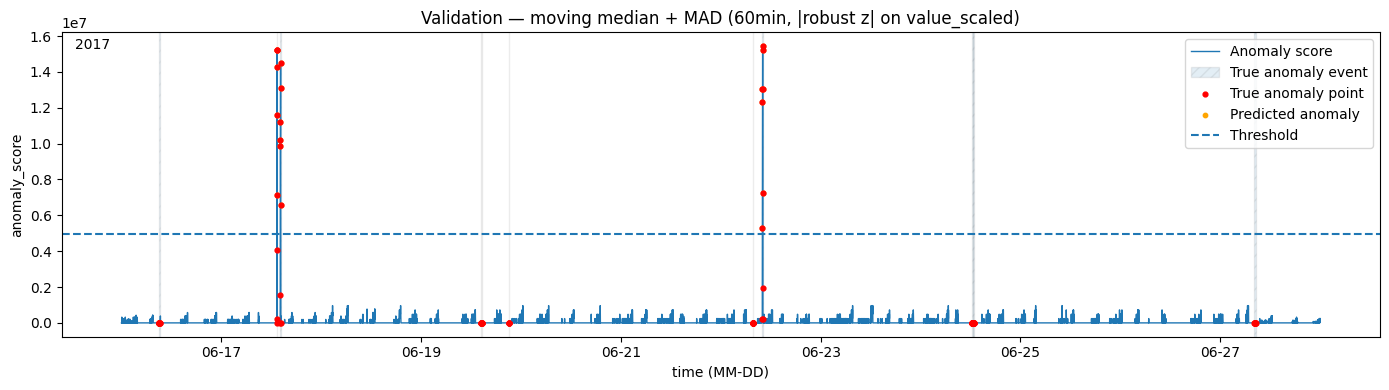

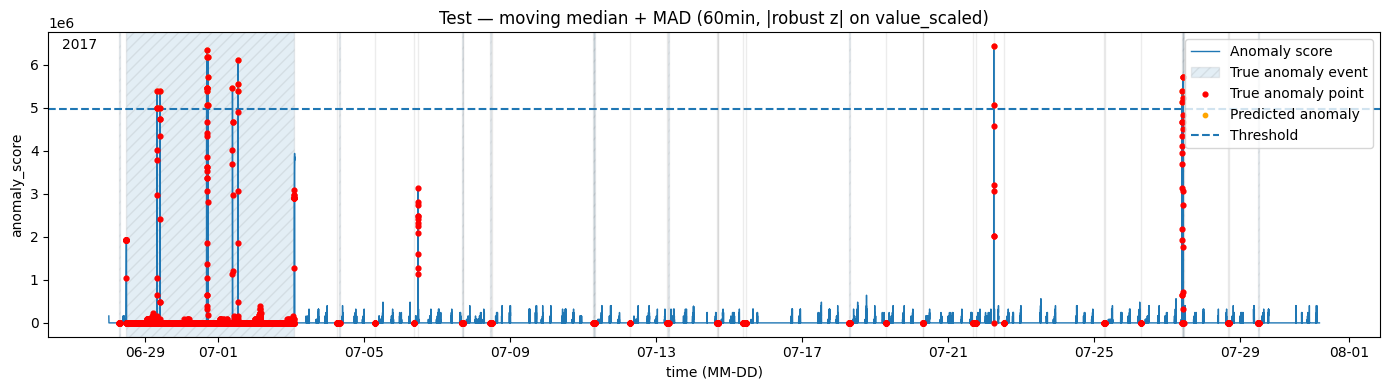

'conservative_threshold_val;threshold=val_event_f1'

In [198]:
# ------------------------------------------------------------
# Step 9: Tier 0 baseline — moving median + MAD (60min) on value_scaled
# ------------------------------------------------------------

import time

# -----------------------------
# 9.1 Moving median + MAD score function (causal, time-based)
# -----------------------------
def compute_causal_time_moving_median_mad_score(
    history_df: pd.DataFrame,
    target_df: pd.DataFrame,
    window: str = "60min",
    min_periods: int = 30,
    mad_epsilon: float = 1e-6,
) -> np.ndarray:
    """
    Compute a causal time-based robust z-score using moving median + MAD on value_scaled.

    Notes
    - Uses a time-based rolling window (e.g., "60min").
    - Uses history_df to warm-start the rolling statistics.
    - Returns scores aligned to target_df row order.
    - MAD is scaled by 1.4826 to be comparable to std under normality.
    - A small epsilon floors the scaled MAD to avoid division-by-zero blowups.

    Output
    - anomaly_score(t) = | (x(t) - moving_median(t)) / max(1.4826 * moving_MAD(t), epsilon) |
    """
    combined = pd.concat([history_df, target_df], ignore_index=True).copy()
    combined = combined.sort_values("time").reset_index(drop=True)

    s = combined.set_index("time")["value_scaled"].astype(float)

    moving_median = s.rolling(window=window, min_periods=min_periods).median()
    abs_dev = (s - moving_median).abs()
    moving_mad = abs_dev.rolling(window=window, min_periods=min_periods).median()

    scaled_mad = 1.4826 * moving_mad
    denom = scaled_mad.where(scaled_mad > mad_epsilon, mad_epsilon)

    robust_z = (s - moving_median) / denom
    score = robust_z.abs()

    n_target = len(target_df)
    return score.iloc[-n_target:].to_numpy()


# -----------------------------
# 9.2 Experiment identifiers
# -----------------------------
MODEL_NAME = "heuristic_moving_median_mad_60min_abs_value_scaled"
TIER = 0

MOVING_WINDOW = "60min"
MIN_PERIODS = 30

SCORE_DEFINITION_KEY = f"moving_median_mad_{MOVING_WINDOW}_abs"
SCORE_DEFINITION_TEXT = (
    f"abs((value_scaled - moving_median_{MOVING_WINDOW}) / max(1.4826*moving_MAD_{MOVING_WINDOW}, eps))"
)

THRESHOLD_STRATEGY = "val_event_f1"

# Static time-series score (no window feature table)
WINDOW_LENGTH_L = 0
FEATURE_MODE = "none"
USES_TIME_FEATURES = 0
CONTIGUITY_ENFORCED = 1

# Deterministic run key + overwrite-only folder
run_key = make_run_key(
    case_study=CASE_STUDY,
    tier=TIER,
    model_name=MODEL_NAME,
    window_length_L=WINDOW_LENGTH_L,
    feature_mode=FEATURE_MODE,
    uses_time_features=USES_TIME_FEATURES,
    contiguity_enforced=CONTIGUITY_ENFORCED,
    score_definition_key=SCORE_DEFINITION_KEY,
    threshold_strategy=THRESHOLD_STRATEGY,
)
run_dir = run_dir_from_key(
    run_key=run_key,
    case_study=CASE_STUDY,
    tier=TIER,
    model_slug=MODEL_NAME,
)

# Trace id (recorded only in config)
run_id = make_run_id_timestamp()
run_timestamp = pd.Timestamp.now().isoformat()

# -----------------------------
# 9.3 Compute scores (causal warm-start)
# -----------------------------
t0 = time.time()

# Validation: warm-start from train only
val_scores = compute_causal_time_moving_median_mad_score(
    history_df=train_df[["time", "value_scaled"]].copy(),
    target_df=val_df[["time", "value_scaled"]].copy(),
    window=MOVING_WINDOW,
    min_periods=MIN_PERIODS,
)

# Test: warm-start from train + validation (past only)
test_history = pd.concat(
    [train_df[["time", "value_scaled"]], val_df[["time", "value_scaled"]]],
    ignore_index=True
)
test_scores = compute_causal_time_moving_median_mad_score(
    history_df=test_history.copy(),
    target_df=test_df[["time", "value_scaled"]].copy(),
    window=MOVING_WINDOW,
    min_periods=MIN_PERIODS,
)

train_seconds = 0.0
score_seconds = time.time() - t0

# -----------------------------
# 9.4 Threshold search on validation (event-level)
# -----------------------------
best_thr, thr_table = select_threshold_event_f1(
    df_split=val_df,
    scores=val_scores,
    true_events_split=true_events_val,
    n_grid=60,
)

# -----------------------------
# 9.5 Evaluate at chosen threshold
# -----------------------------
val_metrics = evaluate_at_threshold(val_df, val_scores, best_thr, true_events_val)
test_metrics = evaluate_at_threshold(test_df, test_scores, best_thr, true_events_test)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

display(best_thr)
display(thr_table.head(5))
display(val_metrics_df)
display(test_metrics_df)

# -----------------------------
# 9.6 Predictions + plots (shown and saved)
# -----------------------------
val_pred_flags = (val_scores >= best_thr).astype(int)
test_pred_flags = (test_scores >= best_thr).astype(int)

fig_val = plot_score_timeline(
    df_split=val_df,
    scores=val_scores,
    threshold=best_thr,
    title="Validation — moving median + MAD (60min, |robust z| on value_scaled)",
    true_events_split=true_events_val,
    pred_is_anomaly=val_pred_flags,
)
plt.show()
fig_val.savefig(run_dir / "fig_val_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_val)

fig_test = plot_score_timeline(
    df_split=test_df,
    scores=test_scores,
    threshold=best_thr,
    title="Test — moving median + MAD (60min, |robust z| on value_scaled)",
    true_events_split=true_events_test,
    pred_is_anomaly=test_pred_flags,
)
plt.show()
fig_test.savefig(run_dir / "fig_test_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_test)

# -----------------------------
# 9.7 Save per-run artefacts (overwrite-only folder)
# -----------------------------
config = {
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,
    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,
    "random_seed": RANDOM_SEED,
    "moving_window": MOVING_WINDOW,
    "min_periods": MIN_PERIODS,
    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,
    "threshold_strategy": THRESHOLD_STRATEGY,
}
save_json(config, run_dir / "config.json")

save_json(
    {
        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),
        "validation_best_row": thr_table.iloc[0].to_dict(),
    },
    run_dir / "threshold.json",
)

val_pred = pd.DataFrame({
    "time": val_df["time"],
    "anomaly_score": val_scores,
    "pred_is_anomaly": val_pred_flags,
    "is_anomaly": val_df["is_anomaly"].astype(int),
    "split": "validation",
    "case_study": CASE_STUDY,
})
test_pred = pd.DataFrame({
    "time": test_df["time"],
    "anomaly_score": test_scores,
    "pred_is_anomaly": test_pred_flags,
    "is_anomaly": test_df["is_anomaly"].astype(int),
    "split": "test",
    "case_study": CASE_STUDY,
})

save_df(val_pred, run_dir / "val_predictions.csv")
save_df(test_pred, run_dir / "test_predictions.csv")
save_df(val_metrics_df, run_dir / "val_metrics.csv")
save_df(test_metrics_df, run_dir / "test_metrics.csv")
save_df(thr_table, run_dir / "val_threshold_grid.csv")

# -----------------------------
# 9.8 Log performance-only results (UPSERT by run_key) — mirrored from Step 8
# -----------------------------
notes = auto_notes(
    val_event_precision=float(val_metrics["event_precision"]),
    val_event_recall=float(val_metrics["event_recall"]),
    val_event_f1=float(val_metrics["event_f1"]),
    test_event_precision=float(test_metrics["event_precision"]),
    test_event_recall=float(test_metrics["event_recall"]),
    test_event_f1=float(test_metrics["event_f1"]),
    test_pr_auc=float(test_metrics["pr_auc"]),
    threshold_strategy=THRESHOLD_STRATEGY,
)

row = normalise_perf_row({
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,

    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,

    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,

    "threshold_strategy": THRESHOLD_STRATEGY,
    "threshold_value": float(best_thr),

    "val_event_precision": float(val_metrics["event_precision"]),
    "val_event_recall": float(val_metrics["event_recall"]),
    "val_event_f1": float(val_metrics["event_f1"]),
    "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),

    "test_event_precision": float(test_metrics["event_precision"]),
    "test_event_recall": float(test_metrics["event_recall"]),
    "test_event_f1": float(test_metrics["event_f1"]),
    "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),

    "test_point_precision": float(test_metrics["point_precision"]),
    "test_point_recall": float(test_metrics["point_recall"]),
    "test_point_f1": float(test_metrics["point_f1"]),
    "test_auroc": float(test_metrics["auroc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),

    "train_seconds": float(train_seconds),
    "score_seconds": float(score_seconds),

    "notes": notes,
})
upsert_all_results_row(row)
notes


## Step 9 - Interpretation: Tier 0 moving median + MAD baseline (60-minute robust moving window)

### What was implemented
This Tier 0 baseline uses robust local statistics to score each timestamp:

- moving_median(t): time-based moving median of `value_scaled` over a 60-minute window  
- moving_MAD(t): time-based moving median absolute deviation over the same window  
- robust_z(t) = (value_scaled(t) − moving_median(t)) / (1.4826 · moving_MAD(t))  
- **anomaly_score(t) = |robust_z(t)|**

A single threshold was selected on **validation only** by maximising **event-level F1**, then applied unchanged to test.

---

### Threshold selection outcome (validation)
- **Chosen threshold:** approximately **4.97 × 10^8** (very large)
- **Unfloored MAD (epsilon safeguard)** = exhibits heavy-tail instability in Case D.
- - This is valuable evidence of why some simple robust heuristics can be brittle under operational KPI conditions.

**Validation (primary: event-level)**
- **Event precision = 1.000**
- **Event recall = 0.273**
- **Event F1 = 0.429**
- **Median detection delay = 1 minute**

**Validation (secondary: point-wise)**
- **Point precision = 1.000**
- **Point recall = 0.186**
- **Point F1 = 0.313**
- **AUROC ≈ 0.842**
- **PR-AUC ≈ 0.234**

Interpretation:
- The selected threshold is **extremely conservative**, which is consistent with event precision = 1.0 (few predicted events, and those predicted overlap true events).
- Event recall is low (~0.27), meaning most true validation events are **not detected** under this threshold.
- The unusually large threshold strongly suggests the score distribution contains **rare, massive spikes** in |robust_z| (likely when the moving MAD becomes extremely small), producing very large values even after the epsilon safeguard.

---

### Test performance (headline)
**Test (primary: event-level)**
- **Event precision = 1.000**
- **Event recall = 0.105**
- **Event F1 = 0.190**
- **Median detection delay = 4.5 minutes**

**Test (secondary: point-wise)**
- **Point precision = 1.000**
- **Point recall = 0.00371**
- **Point F1 = 0.00740**
- **AUROC ≈ 0.219**
- **PR-AUC ≈ 0.156**

Interpretation:
- Generalisation is weak for event detection: only ~10.5% of test events receive any hit.
- Compared to the Step 8 moving z-score baseline, event recall is markedly lower, indicating this robust baseline is **too strict** for the incident-heavy test regime.
- Detection delay increases in test (median 4.5 minutes), consistent with only the strongest spikes exceeding the threshold, often later into an event.

---

### Plot-based interpretation (validation vs test)
**Validation plot**
- Most of the score mass sits near zero, with a few extremely tall spikes (on the order of 10^9).
- The selected threshold lies high and only intersects the tallest spikes.
- This explains the pattern: very high precision, but low recall.

**Test plot**
- The incident region (early test) shows many true anomaly points/events, but only a small subset produce the “giant spike” behaviour that clears the threshold.
- Predicted anomalies occur as isolated hits rather than consistent coverage across events, consistent with extremely low point-wise recall.

---

### Why the score magnitude is extreme (important diagnostic)
The magnitude scale (~10^8–10^9) is not inherently meaningful; it signals instability in the denominator:

- If the moving MAD in a window becomes very small (near 0), then:
  - |robust_z| can explode even for modest deviations.
- This can happen in “flat” or near-constant segments, which are plausible in operational KPI monitoring.
- Even with an epsilon, the resulting score distribution becomes heavy-tailed, and threshold search tends to choose a high cutoff that yields perfect precision but suppressed recall.

This behaviour should be documented as a limitation of this specific robust formulation under Case D conditions.

---

### Tie back to the research objectives and Case D role
**Event-level objective (primary):**
- This baseline demonstrates that a robust local-normalisation heuristic can achieve perfect precision but can fail to detect most events in the incident regime (low recall).
- This directly supports the dissertation’s argument that **headline evaluation must be event-level**, because point-wise metrics alone would not capture the practical requirement: “Does the method detect incidents?”

**Drift/incident stress test:**
- Case D was intentionally designed as a stress test with dense incidents in test.
- The validation-selected threshold does not transfer well to the test incident regime, reinforcing the proposal’s emphasis on **drift-aware evaluation** and regime sensitivity.

**Efficiency and baseline anchoring:**
- This is computationally light and reproducible, satisfying feasibility constraints.
- However, it sets a clear baseline limitation: purely local robust statistics can be overly conservative and unstable in flat segments, motivating Tier 1 window-feature baselines and later deep/diffusion methods.

---

### Practical takeaway for Tier 0 → Tier 1 progression
- Among Tier 0 heuristics so far, this method appears to be the **most conservative** and least effective for event detection in Case D.
- The Step 8 moving z-score baseline is a stronger Tier 0 reference for detecting incident events.
- Tier 1 models (Isolation Forest, OC-SVM) should now focus on window-level features that can capture incident structure beyond isolated denominator-driven spikes.


## Step 10 - Tier 0 baseline: moving median + MAD with train-derived MAD floor (stabilised)


The unfloored moving MAD baseline in step 9 can produce heavy-tailed anomaly scores when the moving MAD becomes extremely small
(e.g., near-flat segments), causing interpretability and threshold stability issues.

This step introduces a **train-derived MAD floor**:

- Compute moving MAD values on the **training split only**.
- Define `mad_floor` as a low percentile of positive moving MAD values (e.g., 5th percentile).
- Use a floored denominator:

  denom(t) = max(1.4826 * moving_MAD(t), 1.4826 * mad_floor)

This prevents score blow-ups while respecting the charter’s leakage rules:
- the floor is estimated from training only,
- threshold selection remains validation-only using event-level F1,
- test remains report-only.


{'mad_floor_train_q05': 0.08039217402605947}

53.6612445360378

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,53.661245,1.000000,0.363636,0.533333,1.000000,0.185567,0.313043,0.907228,0.684305,2.0
1,8.093874,0.344828,0.909091,0.500000,0.746835,0.608247,0.670455,0.907228,0.684305,1.0
2,6.070405,0.141176,1.000000,0.247423,0.384615,0.670103,0.488722,0.907228,0.684305,1.0
3,5.058671,0.127451,1.000000,0.226087,0.347150,0.690722,0.462069,0.907228,0.684305,1.0
4,4.046937,0.049180,1.000000,0.093750,0.169048,0.731959,0.274662,0.907228,0.684305,1.0


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,1.0,0.363636,0.533333,2.0,1.0,0.185567,0.313043,0.907228,0.684305


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,1.0,0.026316,0.051282,4.0,1.0,0.000143,0.000285,0.217925,0.184899


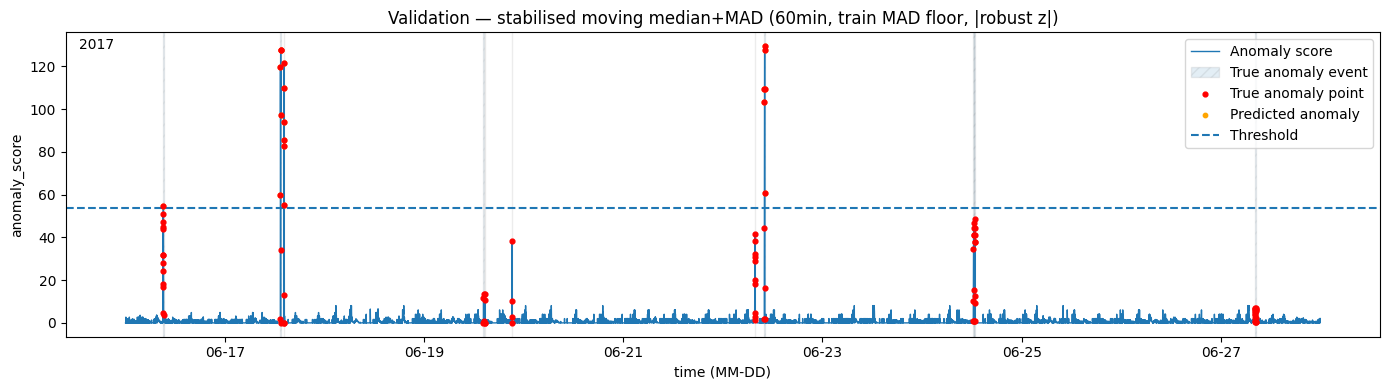

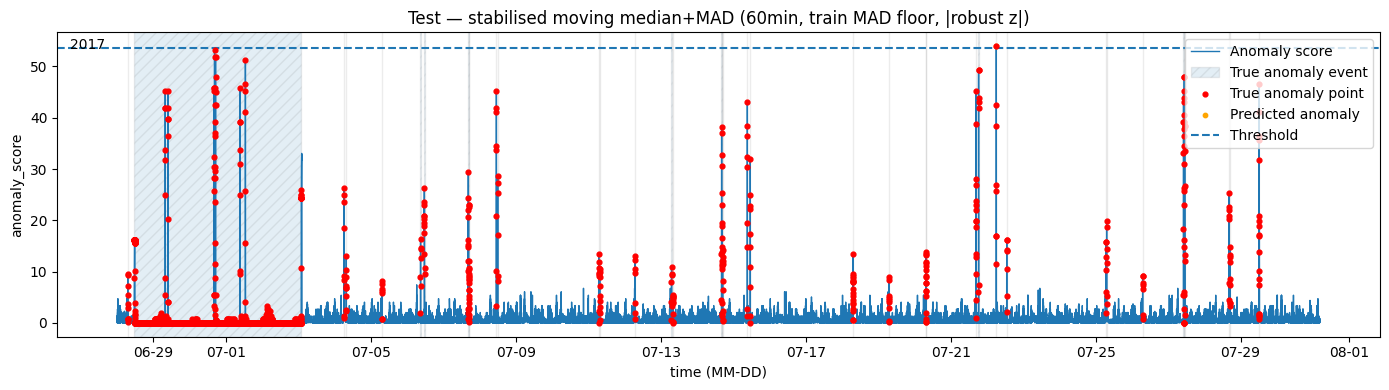

'conservative_threshold_test;conservative_threshold_val;val_to_test_drop_calibration_shift_suspected;threshold=val_event_f1'

In [199]:
# ------------------------------------------------------------
# ## Step 10 - Tier 0 baseline: moving median + MAD (60min) with train-derived MAD floor (stabilised)
# ------------------------------------------------------------

import time

# -----------------------------
# 10.1 Stabilised moving MAD score function (causal, time-based)
# -----------------------------
def compute_causal_time_moving_median_mad_score_stabilised(
    history_df: pd.DataFrame,
    target_df: pd.DataFrame,
    train_df_for_floor: pd.DataFrame,
    window: str = "60min",
    min_periods: int = 30,
    mad_floor_quantile: float = 0.05,
) -> tuple[np.ndarray, float]:
    """
    Compute a causal robust z-score using moving median + MAD on value_scaled,
    stabilised with a train-derived MAD floor to prevent heavy-tail blow-ups.

    Design
    - Compute moving median and moving MAD on the combined (history + target) series.
    - Derive a small positive MAD floor from training windows:
        mad_floor = quantile_q(moving_mad_train, q=mad_floor_quantile)
    - Use:
        denom(t) = max(1.4826*moving_mad(t), 1.4826*mad_floor)
      instead of an epsilon floor.

    Output
    - Returns:
        (scores aligned to target_df row order, mad_floor value)
    """
    # --- Train-derived MAD floor (computed only from train) ---
    train_s = train_df_for_floor.sort_values("time").set_index("time")["value_scaled"].astype(float)

    train_median = train_s.rolling(window=window, min_periods=min_periods).median()
    train_abs_dev = (train_s - train_median).abs()
    train_mad = train_abs_dev.rolling(window=window, min_periods=min_periods).median()

    mad_floor = float(train_mad.dropna().quantile(mad_floor_quantile))
    if not np.isfinite(mad_floor) or mad_floor <= 0:
        # Extremely defensive fallback (should rarely trigger)
        mad_floor = float(train_mad.dropna().median())
        if not np.isfinite(mad_floor) or mad_floor <= 0:
            mad_floor = 1e-6

    # --- Causal warm-start scoring on history + target ---
    combined = pd.concat([history_df, target_df], ignore_index=True).copy()
    combined = combined.sort_values("time").reset_index(drop=True)

    s = combined.set_index("time")["value_scaled"].astype(float)

    moving_median = s.rolling(window=window, min_periods=min_periods).median()
    abs_dev = (s - moving_median).abs()
    moving_mad = abs_dev.rolling(window=window, min_periods=min_periods).median()

    scaled_mad = 1.4826 * moving_mad
    scaled_floor = 1.4826 * mad_floor

    denom = scaled_mad.where(scaled_mad > scaled_floor, scaled_floor)
    robust_z = (s - moving_median) / denom
    score = robust_z.abs()

    n_target = len(target_df)
    return score.iloc[-n_target:].to_numpy(), mad_floor


# -----------------------------
# 10.2 Experiment identifiers
# -----------------------------
MODEL_NAME = "heuristic_moving_median_mad_floor_60min_abs_value_scaled"
TIER = 0

MOVING_WINDOW = "60min"
MIN_PERIODS = 30
MAD_FLOOR_Q = 0.05

SCORE_DEFINITION_KEY = f"moving_median_mad_floor_q{MAD_FLOOR_Q}_{MOVING_WINDOW}_abs"
SCORE_DEFINITION_TEXT = (
    f"abs((value_scaled - moving_median_{MOVING_WINDOW}) / max(1.4826*moving_MAD_{MOVING_WINDOW}, 1.4826*mad_floor_train_q={MAD_FLOOR_Q}))"
)

THRESHOLD_STRATEGY = "val_event_f1"

# Static time-series score (no window feature table)
WINDOW_LENGTH_L = 0
FEATURE_MODE = "none"
USES_TIME_FEATURES = 0
CONTIGUITY_ENFORCED = 1

# Deterministic run key + overwrite-only folder
run_key = make_run_key(
    case_study=CASE_STUDY,
    tier=TIER,
    model_name=MODEL_NAME,
    window_length_L=WINDOW_LENGTH_L,
    feature_mode=FEATURE_MODE,
    uses_time_features=USES_TIME_FEATURES,
    contiguity_enforced=CONTIGUITY_ENFORCED,
    score_definition_key=SCORE_DEFINITION_KEY,
    threshold_strategy=THRESHOLD_STRATEGY,
)
run_dir = run_dir_from_key(
    run_key=run_key,
    case_study=CASE_STUDY,
    tier=TIER,
    model_slug=MODEL_NAME,
)

# Trace id (recorded only in config)
run_id = make_run_id_timestamp()
run_timestamp = pd.Timestamp.now().isoformat()

# -----------------------------
# 10.3 Compute scores (causal warm-start) + derive MAD floor from train
# -----------------------------
t0 = time.time()

# Validation: warm-start from train only (floor derived from train only)
val_scores, mad_floor = compute_causal_time_moving_median_mad_score_stabilised(
    history_df=train_df[["time", "value_scaled"]].copy(),
    target_df=val_df[["time", "value_scaled"]].copy(),
    train_df_for_floor=train_df[["time", "value_scaled"]].copy(),
    window=MOVING_WINDOW,
    min_periods=MIN_PERIODS,
    mad_floor_quantile=MAD_FLOOR_Q,
)

# Test: warm-start from train + validation (past only); floor still from train only
test_history = pd.concat(
    [train_df[["time", "value_scaled"]], val_df[["time", "value_scaled"]]],
    ignore_index=True
)
test_scores, _ = compute_causal_time_moving_median_mad_score_stabilised(
    history_df=test_history.copy(),
    target_df=test_df[["time", "value_scaled"]].copy(),
    train_df_for_floor=train_df[["time", "value_scaled"]].copy(),
    window=MOVING_WINDOW,
    min_periods=MIN_PERIODS,
    mad_floor_quantile=MAD_FLOOR_Q,
)

train_seconds = 0.0
score_seconds = time.time() - t0

# -----------------------------
# 10.4 Threshold search on validation (event-level)
# -----------------------------
best_thr, thr_table = select_threshold_event_f1(
    df_split=val_df,
    scores=val_scores,
    true_events_split=true_events_val,
    n_grid=60,
)

# -----------------------------
# 10.5 Evaluate at chosen threshold
# -----------------------------
val_metrics = evaluate_at_threshold(val_df, val_scores, best_thr, true_events_val)
test_metrics = evaluate_at_threshold(test_df, test_scores, best_thr, true_events_test)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

display({"mad_floor_train_q05": mad_floor})
display(best_thr)
display(thr_table.head(5))
display(val_metrics_df)
display(test_metrics_df)

# -----------------------------
# 10.6 Predictions + plots (shown and saved)
# -----------------------------
val_pred_flags = (val_scores >= best_thr).astype(int)
test_pred_flags = (test_scores >= best_thr).astype(int)

fig_val = plot_score_timeline(
    df_split=val_df,
    scores=val_scores,
    threshold=best_thr,
    title="Validation — stabilised moving median+MAD (60min, train MAD floor, |robust z|)",
    true_events_split=true_events_val,
    pred_is_anomaly=val_pred_flags,
)
plt.show()
fig_val.savefig(run_dir / "fig_val_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_val)

fig_test = plot_score_timeline(
    df_split=test_df,
    scores=test_scores,
    threshold=best_thr,
    title="Test — stabilised moving median+MAD (60min, train MAD floor, |robust z|)",
    true_events_split=true_events_test,
    pred_is_anomaly=test_pred_flags,
)
plt.show()
fig_test.savefig(run_dir / "fig_test_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_test)

# -----------------------------
# 10.7 Save per-run artefacts (overwrite-only folder)
# -----------------------------
config = {
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,
    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,
    "random_seed": RANDOM_SEED,
    "moving_window": MOVING_WINDOW,
    "min_periods": MIN_PERIODS,
    "mad_floor_quantile": MAD_FLOOR_Q,
    "mad_floor_value_train": float(mad_floor),
    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,
    "threshold_strategy": THRESHOLD_STRATEGY,
}
save_json(config, run_dir / "config.json")

save_json(
    {
        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),
        "validation_best_row": thr_table.iloc[0].to_dict(),
    },
    run_dir / "threshold.json",
)

val_pred = pd.DataFrame({
    "time": val_df["time"],
    "anomaly_score": val_scores,
    "pred_is_anomaly": val_pred_flags,
    "is_anomaly": val_df["is_anomaly"].astype(int),
    "split": "validation",
    "case_study": CASE_STUDY,
})
test_pred = pd.DataFrame({
    "time": test_df["time"],
    "anomaly_score": test_scores,
    "pred_is_anomaly": test_pred_flags,
    "is_anomaly": test_df["is_anomaly"].astype(int),
    "split": "test",
    "case_study": CASE_STUDY,
})

save_df(val_pred, run_dir / "val_predictions.csv")
save_df(test_pred, run_dir / "test_predictions.csv")
save_df(val_metrics_df, run_dir / "val_metrics.csv")
save_df(test_metrics_df, run_dir / "test_metrics.csv")
save_df(thr_table, run_dir / "val_threshold_grid.csv")

# -----------------------------
# 10.8 Log performance-only results (UPSERT by run_key) — mirrored from Step 8
# -----------------------------
notes = auto_notes(
    val_event_precision=float(val_metrics["event_precision"]),
    val_event_recall=float(val_metrics["event_recall"]),
    val_event_f1=float(val_metrics["event_f1"]),
    test_event_precision=float(test_metrics["event_precision"]),
    test_event_recall=float(test_metrics["event_recall"]),
    test_event_f1=float(test_metrics["event_f1"]),
    test_pr_auc=float(test_metrics["pr_auc"]),
    threshold_strategy=THRESHOLD_STRATEGY,
)

row = normalise_perf_row({
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,

    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,

    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,

    "threshold_strategy": THRESHOLD_STRATEGY,
    "threshold_value": float(best_thr),

    "val_event_precision": float(val_metrics["event_precision"]),
    "val_event_recall": float(val_metrics["event_recall"]),
    "val_event_f1": float(val_metrics["event_f1"]),
    "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),

    "test_event_precision": float(test_metrics["event_precision"]),
    "test_event_recall": float(test_metrics["event_recall"]),
    "test_event_f1": float(test_metrics["event_f1"]),
    "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),

    "test_point_precision": float(test_metrics["point_precision"]),
    "test_point_recall": float(test_metrics["point_recall"]),
    "test_point_f1": float(test_metrics["point_f1"]),
    "test_auroc": float(test_metrics["auroc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),

    "train_seconds": float(train_seconds),
    "score_seconds": float(score_seconds),

    "notes": notes,
})
upsert_all_results_row(row)
notes


## Step 10 - Interpretation: Tier 0 moving median + MAD baseline with train-derived MAD floor (60-minute robust moving window)

### What was implemented (and why)
This step re-runs the robust moving median + MAD heuristic, but **stabilises the denominator** to prevent score blow-ups observed in the unfloored version.

Scoring definition:
- moving_median(t): 60-minute moving median of `value_scaled`
- moving_MAD(t): 60-minute moving median absolute deviation
- A **MAD floor** is computed from **training only** (q=0.05 of positive moving MAD values on train)
- Denominator uses the floor:
  - denom(t) = max(1.4826 * moving_MAD(t), 1.4826 * mad_floor_train)
- anomaly_score(t) = | (value_scaled(t) − moving_median(t)) / denom(t) |

Charter alignment:
- The stabilisation constant is estimated using **training data only** (no validation/test leakage).
- Threshold selection remains **validation-only** using **event-level F1**.
- Test remains report-only.

---

### Immediate diagnostic: score scale is now interpretable
Compared to Step 9 (unfloored) where scores reached ~1e9, the floored version yields scores in an interpretable range (roughly 0–120 in validation, ~0–55 in test as seen on the plots). This confirms the floor is doing its job: preventing near-zero MAD from creating heavy-tailed explosions.

This is an important methodological improvement for:
- interpretability of score magnitude,
- stability of threshold search,
- and fairness when comparing to other baselines.

---

### Threshold selection outcome (validation)
- **Chosen threshold:** ~**53.66** (selected by validation event-F1)

From the validation metrics at the selected threshold:

**Validation (primary: event-level)**
- **Event precision = 1.000**
- **Event recall = 0.364**
- **Event F1 = 0.533**
- **Median detection delay = 2 minutes**

**Validation (secondary: point-wise)**
- **Point precision = 1.000**
- **Point recall = 0.1856**
- **Point F1 = 0.313**
- **AUROC ≈ 0.907**
- **PR-AUC ≈ 0.680**

Interpretation:
- Thresholding remains **conservative** (precision 1.0), but recall improves vs Step 9 (unfloored) on validation.
- The **ranking metrics** (AUROC and PR-AUC) are strong on validation, indicating the stabilised score provides good discrimination *in the validation regime*.
- Despite good ranking, point-wise recall at the chosen operating point is still low—detections are sparse spikes rather than sustained coverage inside events. This matches the visible behaviour: a high threshold targets only the strongest deviations.

---

### Test performance (headline)
**Test (primary: event-level)**
- **Event precision = 1.000**
- **Event recall = 0.0263**
- **Event F1 = 0.0513**
- **Median detection delay = 4 minutes**

**Test (secondary: point-wise)**
- **Point precision = 1.000**
- **Point recall ≈ 0.000143**
- **Point F1 ≈ 0.000285**
- **AUROC ≈ 0.219**
- **PR-AUC ≈ 0.1849**

Interpretation:
- Generalisation to the incident-heavy test regime is extremely poor at the selected threshold:
  - only ~2.6% of test events are detected at least once.
- AUROC collapses in test, and PR-AUC drops sharply relative to validation.
- The combination “high precision + near-zero recall” indicates the validation-selected threshold is **too strict for the test regime**, consistent with calibration or distribution shift.

---

### Plot-based interpretation (validation vs test)
**Validation plot**
- A few strong peaks exceed the threshold and align with true anomaly points/events.
- The threshold line is high, resulting in relatively few predicted anomaly points.
- This supports the validation metrics: perfect precision, moderate event recall, low point recall.

**Test plot**
- The early incident period contains dense anomalies, but the score rarely exceeds the high threshold.
- This yields almost no predicted anomaly points inside most true events, explaining the near-zero event recall.
- Detection delay increases (median 4 minutes), consistent with only late or extreme portions of some events crossing the threshold.

---

### Key finding: stabilising the score fixes interpretability, but not regime transfer
This baseline demonstrates two distinct issues:

1. **Score instability issue (solved)**
   - The MAD floor successfully removes the heavy-tailed numerical pathology.
   - Scores become interpretable and threshold search becomes numerically meaningful.

2. **Regime transfer / drift issue (not solved)**
   - Despite strong validation AUROC/PR-AUC, test event recall collapses.
   - This suggests a **distribution shift** between validation and test (consistent with the Case D design: test contains the incident regime).
   - As a result, a validation-optimised high threshold does not translate into incident detection.

This is directly relevant to the proposal’s drift-aware motivation: even when a baseline looks good on validation, it may fail under a later incident regime.

---

### Comparison to earlier Tier 0 baselines (qualitative)
- Relative to Step 9 (unfloored moving MAD):
  - This version is strictly better from an engineering/scientific standpoint (stable scores; improved validation event recall).
- Relative to Step 8 (moving z-score 60min):
  - Step 8 achieved materially higher test event recall (even if imperfect).
  - The stabilised MAD baseline is still too conservative under incident conditions.

This implies the robust MAD formulation (even stabilised) may be less suitable as a primary Tier 0 detector for Case D’s incident regime, but it remains useful as an interpretable conservative anchor.

---

### Tie to the research aims (why this matters)
- **Event-level evaluation (primary objective):** event recall exposes a failure mode that point-wise ranking metrics can hide. Validation AUROC/PR-AUC are strong, yet test event detection is near absent.
- **Drift-aware evaluation:** Case D is intended to stress-test incident regimes; the observed validation→test collapse provides concrete evidence supporting the dissertation’s focus on robustness under regime change.
- **Efficiency constraints:** this is still a lightweight heuristic baseline. Its limitations justify the need for Tier 1 window-feature models (IF, OC-SVM) and later sequence models (LSTM AE, diffusion) that may handle regime structure more effectively.

---

### Practical takeaway before proceeding
- The MAD floor is a defensible stabilisation and should be retained for interpretability.
- However, the operating point chosen by validation event-F1 is too conservative for test incidents in Case D.
- Tier 1 models should now be evaluated to determine whether window-based representations improve event recall under the incident regime without triggering excessive false predicted events.


## Step 11 - Tier 1 window features (vectorised, contiguity-aware)


This step constructs window-level (tabular) features for Tier 1 baselines (Isolation Forest and OC-SVM).
Each row represents one window ending at time t, with labels taken at the window end (point label) and with
optional contiguity enforcement to exclude windows that cross non-contiguous time gaps.


In [208]:
import numpy as np
import pandas as pd
from typing import Tuple, Dict, Any

# -----------------------------
# 11.1 Vectorised window feature builder (summary stats)
# -----------------------------
def _valid_window_end_mask_1min(times: np.ndarray, L: int) -> np.ndarray:
    """
    Build a boolean mask over indices [0..n-1] marking which indices can be valid
    window ends for length L under strict 1-minute contiguity.

    A window ending at index i is valid if the last L timestamps are consecutive 1-minute steps.
    """
    n = len(times)
    if n == 0:
        return np.zeros(0, dtype=bool)

    # Breakpoints where contiguity fails (including first index)
    # diff in minutes between consecutive timestamps
    dt = np.diff(times).astype("timedelta64[m]").astype(int)
    breaks = np.concatenate([[True], dt != 1])  # True means "new run starts here"

    # For each index, compute position within its contiguous run
    # start_idx_of_run[i] = most recent index j<=i where breaks[j] is True
    idx = np.arange(n)
    start_idx_of_run = np.maximum.accumulate(np.where(breaks, idx, 0))
    run_pos = idx - start_idx_of_run + 1  # 1..run_length

    return run_pos >= L


def build_window_features_summary(
    df: pd.DataFrame,
    L: int,
    value_col: str = "value_scaled",
    contiguity_enforced: int = 1,
    uses_time_features: int = 1,
) -> Tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    """
    Build a window-level feature table (summary mode) in a vectorised way.

    Features (per window):
      - mean, std, min, max, last
      - slope (least-squares on index 0..L-1)
    Optional:
      - append time-derived features at window end: hour_of_day, day_of_week, is_weekend

    Labels:
      - y is the point label at the window end: df["is_anomaly"] at time t_end

    Meta:
      - time_end, split, is_anomaly_end, (event_id_end if present)
    """
    if L <= 0:
        raise ValueError("L must be a positive integer for Tier 1 window features.")

    required = ["time", value_col, "is_anomaly", "split"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    df_local = df.sort_values("time").reset_index(drop=True).copy()

    times = df_local["time"].to_numpy(dtype="datetime64[ns]")
    values = df_local[value_col].astype(float).to_numpy()
    y_point = df_local["is_anomaly"].astype(int).to_numpy()

    n = len(df_local)
    if n < L:
        X = pd.DataFrame()
        y = np.array([], dtype=int)
        meta = pd.DataFrame(columns=["time", "split", "is_anomaly"])
        return X, y, meta

    # Sliding windows (shape: (n-L+1, L))
    w = np.lib.stride_tricks.sliding_window_view(values, window_shape=L)

    # Window ends correspond to indices [L-1 .. n-1]
    end_idx = np.arange(L - 1, n)

    if contiguity_enforced == 1:
        valid_end = _valid_window_end_mask_1min(times, L)[end_idx]
    else:
        valid_end = np.ones(len(end_idx), dtype=bool)

    w = w[valid_end]
    end_idx = end_idx[valid_end]

    # Summary features
    w_mean = w.mean(axis=1)
    w_std = w.std(axis=1, ddof=0)
    w_min = w.min(axis=1)
    w_max = w.max(axis=1)
    w_last = w[:, -1]

    # Slope: cov(t, x) / var(t), with t = 0..L-1
    t = np.arange(L, dtype=float)
    t_centered = t - t.mean()
    var_t = float((t_centered ** 2).sum())
    w_slope = (w @ t_centered) / var_t

    X = pd.DataFrame({
        "w_mean": w_mean,
        "w_std": w_std,
        "w_min": w_min,
        "w_max": w_max,
        "w_last": w_last,
        "w_slope": w_slope,
    })

    # Optional time features at window end
    if uses_time_features == 1:
        for tc in ["hour_of_day", "day_of_week", "is_weekend"]:
            if tc not in df_local.columns:
                raise ValueError(f"uses_time_features=1 but missing column: {tc}")
        X["hour_of_day"] = df_local.loc[end_idx, "hour_of_day"].astype(int).to_numpy()
        X["day_of_week"] = df_local.loc[end_idx, "day_of_week"].astype(int).to_numpy()
        X["is_weekend"] = df_local.loc[end_idx, "is_weekend"].astype(int).to_numpy()

    # y at window end
    y = y_point[end_idx]

    # meta
    meta_cols = {
        "time": df_local.loc[end_idx, "time"].to_numpy(),
        "split": df_local.loc[end_idx, "split"].astype(str).to_numpy(),
        "is_anomaly": y,
    }
    if "event_id" in df_local.columns:
        meta_cols["event_id"] = df_local.loc[end_idx, "event_id"].to_numpy()

    meta = pd.DataFrame(meta_cols)

    return X, y, meta


# -----------------------------
# 11.2 Build Tier 1 window features for each split
# -----------------------------
# Uses the same L you already set (screenshot shows L=60)
L = int(WINDOW_LENGTH_L)

# For Tier 1 windows, contiguity should remain enforced (same principle used earlier)
CONTIGUITY_ENFORCED_T1 = 1

# Use time features at window end (Tier 0–1 “richer features where appropriate”)
USES_TIME_FEATURES_T1 = 1

X_train, y_train, meta_train = build_window_features_summary(
    df=train_df,
    L=L,
    value_col="value_scaled",
    contiguity_enforced=CONTIGUITY_ENFORCED_T1,
    uses_time_features=USES_TIME_FEATURES_T1,
)

X_val, y_val, meta_val = build_window_features_summary(
    df=val_df,
    L=L,
    value_col="value_scaled",
    contiguity_enforced=CONTIGUITY_ENFORCED_T1,
    uses_time_features=USES_TIME_FEATURES_T1,
)

X_test, y_test, meta_test = build_window_features_summary(
    df=test_df,
    L=L,
    value_col="value_scaled",
    contiguity_enforced=CONTIGUITY_ENFORCED_T1,
    uses_time_features=USES_TIME_FEATURES_T1,
)

# -----------------------------
# 11.3 Quick checks (fast)
# -----------------------------
feature_build_summary = pd.DataFrame([
    {"split": "train", "n_windows": len(X_train), "n_points": len(train_df), "L": L},
    {"split": "validation", "n_windows": len(X_val), "n_points": len(val_df), "L": L},
    {"split": "test", "n_windows": len(X_test), "n_points": len(test_df), "L": L},
])

display(feature_build_summary)
display(X_train.head(3))


,split,n_windows,n_points,L
0,train,62518,63999,60
1,validation,16914,17268,60
2,test,47237,47768,60


,w_mean,w_std,w_min,w_max,w_last,w_slope,hour_of_day,day_of_week,is_weekend
0,-0.602377,0.112189,-0.919925,-0.357181,-0.357181,0.004845,16,6,1
1,-0.595678,0.104784,-0.839533,-0.357181,-0.517965,0.004445,17,6,1
2,-0.591658,0.103048,-0.839533,-0.357181,-0.517965,0.004295,17,6,1


### Step 11 - Output summary: Tier 1 window features (vectorised, contiguity-aware)

**Window configuration**
- Window length: **L = 60** (60-minute context under 1-minute sampling)
- Feature mode: **summary statistics + simple trend** computed on `value_scaled`
- Time features appended at window end: `hour_of_day`, `day_of_week`, `is_weekend`
- Contiguity enforced: **Yes** (windows crossing non-contiguous time gaps are excluded)

**Window counts produced**
- Train: **62,518** windows from **63,999** points  
- Validation: **16,914** windows from **17,268** points  
- Test: **47,237** windows from **47,768** points  

The number of windows is lower than the theoretical maximum (`n_points − (L−1)`) because contiguity enforcement removes windows that cross time gaps. This is expected for the AIOps KPI series, which contains occasional missing periods in the time axis.

**Feature table preview**
The resulting Tier 1 feature matrix includes:
- window summaries: `w_mean`, `w_std`, `w_min`, `w_max`, `w_last`
- local trend proxy: `w_slope`
- time context: `hour_of_day`, `day_of_week`, `is_weekend`

These features will be used as inputs for Tier 1 baselines (Isolation Forest and One-Class SVM), while evaluation remains event-level primary.


## Step 11.1 - Standardise step 11 outputs

In [210]:
# ------------------------------------------------------------
# Step 11.8: Alias Step 11 outputs to the canonical names
# ------------------------------------------------------------
# Goal:
# - Downstream steps expect: X_train_df, X_val_df, X_test_df, meta_train_df, meta_val_df, meta_test_df
# - Step 11 may have produced the same objects under different names.
# - This cell maps existing variables -> canonical aliases (no recomputation).

import pandas as pd

def _pick_first_existing(candidates):
    """Return the first candidate name that exists in globals(), else None."""
    for name in candidates:
        if name in globals() and globals()[name] is not None:
            return name
    return None

# Candidate names commonly used in this notebook pattern
X_train_name = _pick_first_existing(["X_train_df", "train_X_df", "X_train_features_df", "train_features_df", "X_train"])
X_val_name   = _pick_first_existing(["X_val_df", "val_X_df", "X_val_features_df", "val_features_df", "X_val"])
X_test_name  = _pick_first_existing(["X_test_df", "test_X_df", "X_test_features_df", "test_features_df", "X_test"])

meta_train_name = _pick_first_existing(["meta_train_df", "train_meta_df", "meta_train", "train_meta"])
meta_val_name   = _pick_first_existing(["meta_val_df", "val_meta_df", "meta_val", "val_meta"])
meta_test_name  = _pick_first_existing(["meta_test_df", "test_meta_df", "meta_test", "test_meta"])

# Hard fail early if Step 11 truly did not run
missing = []
for label, name in [
    ("X_train", X_train_name), ("X_val", X_val_name), ("X_test", X_test_name),
    ("meta_train", meta_train_name), ("meta_val", meta_val_name), ("meta_test", meta_test_name),
]:
    if name is None:
        missing.append(label)

if missing:
    raise NameError(
        "Step 11 outputs not found for: "
        + ", ".join(missing)
        + ". Re-run Step 11 (window feature build) and confirm it completes."
    )

# Assign canonical aliases (DataFrames are expected here)
X_train_df = globals()[X_train_name]
X_val_df   = globals()[X_val_name]
X_test_df  = globals()[X_test_name]

meta_train_df = globals()[meta_train_name]
meta_val_df   = globals()[meta_val_name]
meta_test_df  = globals()[meta_test_name]

# Minimal sanity checks (shapes must align row-wise)
if not isinstance(X_train_df, pd.DataFrame):
    X_train_df = pd.DataFrame(X_train_df)
if not isinstance(X_val_df, pd.DataFrame):
    X_val_df = pd.DataFrame(X_val_df)
if not isinstance(X_test_df, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test_df)

if not isinstance(meta_train_df, pd.DataFrame):
    meta_train_df = pd.DataFrame(meta_train_df)
if not isinstance(meta_val_df, pd.DataFrame):
    meta_val_df = pd.DataFrame(meta_val_df)
if not isinstance(meta_test_df, pd.DataFrame):
    meta_test_df = pd.DataFrame(meta_test_df)

assert len(X_train_df) == len(meta_train_df), "train: X and meta row counts differ"
assert len(X_val_df) == len(meta_val_df), "validation: X and meta row counts differ"
assert len(X_test_df) == len(meta_test_df), "test: X and meta row counts differ"

display(pd.DataFrame([
    {"split": "train", "X_rows": len(X_train_df), "meta_rows": len(meta_train_df), "n_features": X_train_df.shape[1]},
    {"split": "validation", "X_rows": len(X_val_df), "meta_rows": len(meta_val_df), "n_features": X_val_df.shape[1]},
    {"split": "test", "X_rows": len(X_test_df), "meta_rows": len(meta_test_df), "n_features": X_test_df.shape[1]},
]))


,split,X_rows,meta_rows,n_features
0,train,62518,62518,9
1,validation,16914,16914,9
2,test,47237,47237,9


## Step 12 - Tier 1 baseline: Isolation Forest on window features (event-level thresholding)

### Purpose
This step implements a Tier 1 classical baseline using **Isolation Forest** trained on **window-level features** (produced in Step 11 with window length `L = WINDOW_LENGTH_L`). The primary evaluation objective remains **event-level detection**, with the decision threshold selected on the validation split by maximising **event-level F1** (`val_event_f1`). Point-wise metrics (AUROC, PR-AUC) are computed as secondary diagnostics.

### Key design choices
- **Input representation:** window-feature matrix from Step 11 (summary features such as mean/std/min/max/last/slope plus time features).
- **Model:** `sklearn.ensemble.IsolationForest` trained on **train windows only**.
- **Scoring:** anomaly score is defined as `-decision_function(X)` so that **higher values indicate more anomalous windows**.
- **Threshold selection:** validation-only grid search using event-level F1 (no test leakage).
- **Outputs:** validation/test prediction tables, threshold grid, metrics tables, and validation/test score timelines saved under an overwrite-only run folder keyed by `run_key`. The master results registry (`all_results.csv`) records **performance only** via UPSERT on `run_key`.


0.13188707523787452

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,0.131887,0.900000,1.000000,0.947368,0.149789,0.731959,0.248687,0.955088,0.460745,2.0
1,0.088403,0.666667,1.000000,0.800000,0.154426,0.845361,0.261146,0.955088,0.460745,1.0
2,0.070547,0.555556,1.000000,0.714286,0.131783,0.876289,0.229111,0.955088,0.460745,1.0
3,0.229236,1.000000,0.545455,0.705882,1.000000,0.175258,0.298246,0.955088,0.460745,3.0
4,0.069745,0.526316,1.000000,0.689655,0.117403,0.876289,0.207065,0.955088,0.460745,1.0


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,0.9,1.0,0.947368,2.0,0.149789,0.731959,0.248687,0.955088,0.460745


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,0.676056,0.973684,0.798023,3.0,0.390054,0.071653,0.121066,0.952413,0.621024


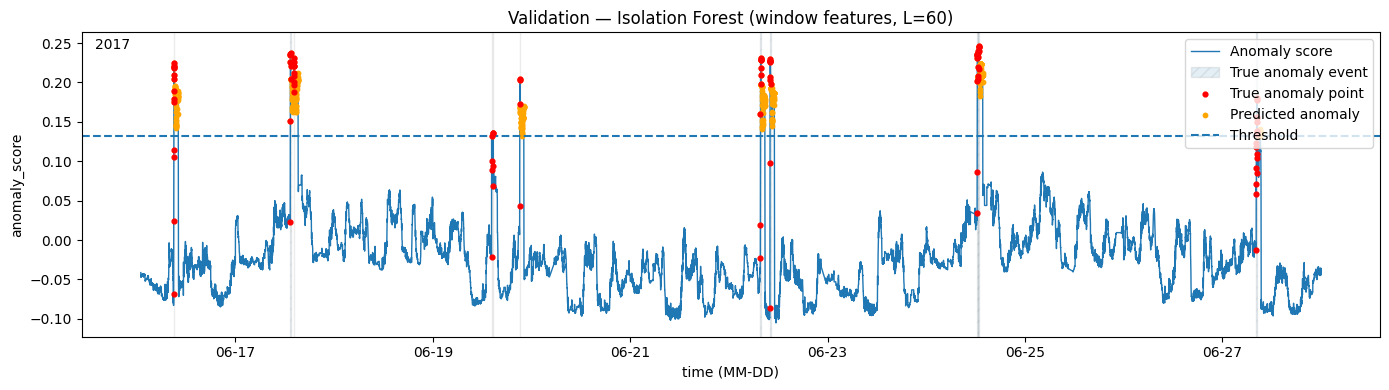

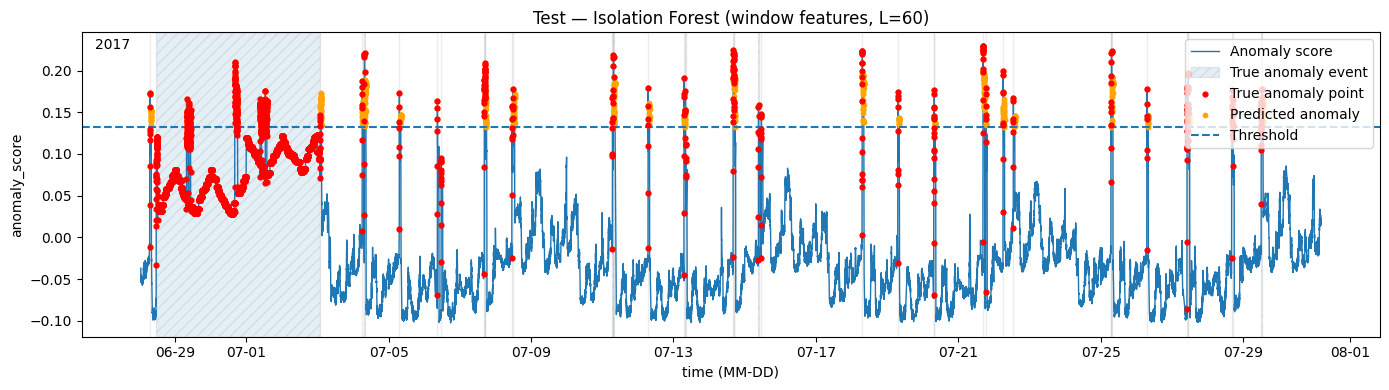

'threshold=val_event_f1'

In [206]:
# ------------------------------------------------------------
# Step 12: Tier 1 baseline — Isolation Forest on window features
# ------------------------------------------------------------

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# -----------------------------
# 12.1 Resolve Step 11 outputs (robust to variable naming)
# -----------------------------
def _pick_first_defined(name_candidates):
    """
    Return the first variable found in globals() from name_candidates.
    """
    for n in name_candidates:
        if n in globals():
            return globals()[n], n
    raise NameError(f"None of these variables were found: {name_candidates}")

# Feature matrices (prefer DataFrame; otherwise accept ndarray)
X_train, _X_train_name = _pick_first_defined(["X_train", "train_X", "X_train_df", "X_train_features"])
X_val, _X_val_name     = _pick_first_defined(["X_val", "val_X", "X_val_df", "X_val_features"])
X_test, _X_test_name   = _pick_first_defined(["X_test", "test_X", "X_test_df", "X_test_features"])

# Window-level meta (must align 1:1 with X_val / X_test)
meta_train, _meta_train_name = _pick_first_defined(["meta_train", "train_meta", "meta_train_df"])
meta_val, _meta_val_name     = _pick_first_defined(["meta_val", "val_meta", "meta_val_df"])
meta_test, _meta_test_name   = _pick_first_defined(["meta_test", "test_meta", "meta_test_df"])

# Window-end labels (optional; used only if meta_* lacks is_anomaly)
y_val, _y_val_name   = _pick_first_defined(["y_val", "val_y", "y_val_end"])
y_test, _y_test_name = _pick_first_defined(["y_test", "test_y", "y_test_end"])

# Ensure meta frames are DataFrames
meta_val = meta_val.copy()
meta_test = meta_test.copy()

# Ensure required columns for plotting/evaluation exist
if "time" not in meta_val.columns or "time" not in meta_test.columns:
    raise KeyError("meta_val/meta_test must contain a 'time' column aligned to window-end timestamps.")

if "is_anomaly" not in meta_val.columns:
    meta_val["is_anomaly"] = np.asarray(y_val).astype(int)

if "is_anomaly" not in meta_test.columns:
    meta_test["is_anomaly"] = np.asarray(y_test).astype(int)

# Split labels (optional but useful in saved predictions)
if "split" not in meta_val.columns:
    meta_val["split"] = "validation"
if "split" not in meta_test.columns:
    meta_test["split"] = "test"

# -----------------------------
# 12.2 Experiment identifiers
# -----------------------------
MODEL_NAME = "isolation_forest_window_features"
TIER = 1

# Window-feature baseline
WINDOW_LENGTH_L = int(WINDOW_LENGTH_L)  # expects Step 11 already set this (e.g., 60)
FEATURE_MODE = "summary"                 # Step 11 output in this notebook is summary-style (w_mean, w_std, ...)
USES_TIME_FEATURES = 1                   # Step 11 includes hour/day/weekend at window end
CONTIGUITY_ENFORCED = 1                  # Step 11 enforces contiguity for windows

SCORE_DEFINITION_KEY = "iforest_neg_decision_function"
SCORE_DEFINITION_TEXT = "IsolationForest score = -decision_function(window_features) (higher = more anomalous)"

THRESHOLD_STRATEGY = "val_event_f1"

# Isolation Forest hyperparameters (keep small + explicit)
IF_N_ESTIMATORS = 200
IF_MAX_SAMPLES = "auto"
IF_RANDOM_STATE = int(RANDOM_SEED)

# Deterministic run key + overwrite-only folder
run_key = make_run_key(
    case_study=CASE_STUDY,
    tier=TIER,
    model_name=MODEL_NAME,
    window_length_L=WINDOW_LENGTH_L,
    feature_mode=FEATURE_MODE,
    uses_time_features=USES_TIME_FEATURES,
    contiguity_enforced=CONTIGUITY_ENFORCED,
    score_definition_key=SCORE_DEFINITION_KEY,
    threshold_strategy=THRESHOLD_STRATEGY,
)
run_dir = run_dir_from_key(
    run_key=run_key,
    case_study=CASE_STUDY,
    tier=TIER,
    model_slug=MODEL_NAME,
)

# Trace id (recorded only in config)
run_id = make_run_id_timestamp()
run_timestamp = pd.Timestamp.now().isoformat()

# -----------------------------
# 12.3 Fit model on train windows (unsupervised)
# -----------------------------
t0 = time.time()

# Convert X to numpy for sklearn if needed
Xtr = X_train.to_numpy() if hasattr(X_train, "to_numpy") else np.asarray(X_train)
Xva = X_val.to_numpy() if hasattr(X_val, "to_numpy") else np.asarray(X_val)
Xte = X_test.to_numpy() if hasattr(X_test, "to_numpy") else np.asarray(X_test)

iforest = IsolationForest(
    n_estimators=IF_N_ESTIMATORS,
    max_samples=IF_MAX_SAMPLES,
    random_state=IF_RANDOM_STATE,
    n_jobs=-1,
)
iforest.fit(Xtr)

train_seconds = float(time.time() - t0)

# -----------------------------
# 12.4 Score validation/test (higher = more anomalous)
# -----------------------------
t1 = time.time()

# decision_function: higher = more normal -> negate to make higher = more anomalous
if hasattr(iforest, "decision_function"):
    val_scores = -iforest.decision_function(Xva)
    test_scores = -iforest.decision_function(Xte)
else:
    # Fallback (older sklearn): score_samples also higher = more normal
    val_scores = -iforest.score_samples(Xva)
    test_scores = -iforest.score_samples(Xte)

score_seconds = float(time.time() - t1)

# -----------------------------
# 12.5 Threshold search on validation (event-level)
# -----------------------------
best_thr, thr_table = select_threshold_event_f1(
    df_split=meta_val,
    scores=val_scores,
    true_events_split=true_events_val,
    n_grid=60,
)

# -----------------------------
# 12.6 Evaluate at chosen threshold
# -----------------------------
val_metrics = evaluate_at_threshold(meta_val, val_scores, best_thr, true_events_val)
test_metrics = evaluate_at_threshold(meta_test, test_scores, best_thr, true_events_test)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

display(best_thr)
display(thr_table.head(5))
display(val_metrics_df)
display(test_metrics_df)

# -----------------------------
# 12.7 Predictions + plots (shown and saved)
# -----------------------------
val_pred_flags = (val_scores >= best_thr).astype(int)
test_pred_flags = (test_scores >= best_thr).astype(int)

fig_val = plot_score_timeline(
    df_split=meta_val,
    scores=val_scores,
    threshold=best_thr,
    title=f"Validation — Isolation Forest (window features, L={WINDOW_LENGTH_L})",
    true_events_split=true_events_val,
    pred_is_anomaly=val_pred_flags,
)
plt.show()
fig_val.savefig(run_dir / "fig_val_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_val)

fig_test = plot_score_timeline(
    df_split=meta_test,
    scores=test_scores,
    threshold=best_thr,
    title=f"Test — Isolation Forest (window features, L={WINDOW_LENGTH_L})",
    true_events_split=true_events_test,
    pred_is_anomaly=test_pred_flags,
)
plt.show()
fig_test.savefig(run_dir / "fig_test_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_test)

# -----------------------------
# 12.8 Save per-run artefacts (overwrite-only folder)
# -----------------------------
config = {
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,
    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,
    "random_seed": int(RANDOM_SEED),

    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,

    "if_n_estimators": int(IF_N_ESTIMATORS),
    "if_max_samples": str(IF_MAX_SAMPLES),
    "if_random_state": int(IF_RANDOM_STATE),

    "score_definition": SCORE_DEFINITION_TEXT,
    "threshold_strategy": THRESHOLD_STRATEGY,
}
save_json(config, run_dir / "config.json")

save_json(
    {
        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),
        "validation_best_row": thr_table.iloc[0].to_dict(),
    },
    run_dir / "threshold.json",
)

val_pred = pd.DataFrame({
    "time": meta_val["time"],
    "anomaly_score": val_scores,
    "pred_is_anomaly": val_pred_flags,
    "is_anomaly": meta_val["is_anomaly"].astype(int),
    "split": "validation",
    "case_study": CASE_STUDY,
})
test_pred = pd.DataFrame({
    "time": meta_test["time"],
    "anomaly_score": test_scores,
    "pred_is_anomaly": test_pred_flags,
    "is_anomaly": meta_test["is_anomaly"].astype(int),
    "split": "test",
    "case_study": CASE_STUDY,
})

save_df(val_pred, run_dir / "val_predictions.csv")
save_df(test_pred, run_dir / "test_predictions.csv")
save_df(val_metrics_df, run_dir / "val_metrics.csv")
save_df(test_metrics_df, run_dir / "test_metrics.csv")
save_df(thr_table, run_dir / "val_threshold_grid.csv")

# -----------------------------
# 12.9 Log performance-only results (UPSERT by run_key)
# -----------------------------
notes = auto_notes(
    val_event_precision=float(val_metrics["event_precision"]),
    val_event_recall=float(val_metrics["event_recall"]),
    val_event_f1=float(val_metrics["event_f1"]),
    test_event_precision=float(test_metrics["event_precision"]),
    test_event_recall=float(test_metrics["event_recall"]),
    test_event_f1=float(test_metrics["event_f1"]),
    test_pr_auc=float(test_metrics["pr_auc"]),
    threshold_strategy=THRESHOLD_STRATEGY,
)

row = normalise_perf_row({
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,

    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,

    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,

    "threshold_strategy": THRESHOLD_STRATEGY,
    "threshold_value": float(best_thr),

    "val_event_precision": float(val_metrics["event_precision"]),
    "val_event_recall": float(val_metrics["event_recall"]),
    "val_event_f1": float(val_metrics["event_f1"]),
    "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),

    "test_event_precision": float(test_metrics["event_precision"]),
    "test_event_recall": float(test_metrics["event_recall"]),
    "test_event_f1": float(test_metrics["event_f1"]),
    "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),

    "test_point_precision": float(test_metrics["point_precision"]),
    "test_point_recall": float(test_metrics["point_recall"]),
    "test_point_f1": float(test_metrics["point_f1"]),
    "test_auroc": float(test_metrics["auroc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),

    "train_seconds": float(train_seconds),
    "score_seconds": float(score_seconds),

    "notes": notes,
})
upsert_all_results_row(row)
notes


## Step 12 - Interpretation: Tier 1 Isolation Forest baseline (window features, L=60)

### What was implemented
This Tier 1 baseline fits an **Isolation Forest** on **window-level tabular features** derived from `value_scaled` using a **60-point window** (L=60).  
A **single threshold** is selected on **validation** by maximising **event-level F1** (`threshold_strategy = val_event_f1`), then applied unchanged to the test split.

---

### Validation results (primary: event-level)
- **Event precision = 0.900**
- **Event recall = 1.000**
- **Event F1 = 0.947**
- **Median event detection delay = 2.0 minutes**

**Interpretation**
- All validation anomaly events are detected (event recall = 1.0), indicating strong sensitivity.
- Event precision below 1.0 indicates some extra predicted events beyond the true labelled events.
- The 2-minute median delay indicates that the detector typically flags anomalies shortly after event onset, consistent with a practical monitoring objective.

---

### Test results (primary: event-level)
- **Event precision = 0.676**
- **Event recall = 0.974**
- **Event F1 = 0.798**
- **Median event detection delay = 3.0 minutes**

**Interpretation**
- Event recall remains very high in test (0.974), meaning almost every true event is detected at least once.
- Event precision drops substantially compared with validation, indicating an increased number of false or redundant predicted events under test conditions.
- The plot supports this: during the incident-heavy region in test, predicted anomaly points appear frequently, which inflates the count of predicted events and reduces event precision.
- Detection delay increases modestly from 2.0 to 3.0 minutes, but remains low.

---

### Secondary diagnostics (point-wise + ranking metrics)
**Validation (point-wise)**
- Point precision ≈ 0.150  
- Point recall ≈ 0.732  
- Point F1 ≈ 0.249  

**Test (point-wise)**
- Point precision ≈ 0.390  
- Point recall ≈ 0.072  
- Point F1 ≈ 0.121  

**Test ranking quality**
- **AUROC ≈ 0.952**
- **PR-AUC ≈ 0.621**

**Interpretation**
- Ranking metrics (AUROC/PR-AUC) indicate the model assigns higher scores to anomalous behaviour more often than normal behaviour, suggesting useful separation in score space.
- Point-wise metrics can look weak or unstable across splits even when event-level detection is strong:
  - Under event-level evaluation, only one detection inside an event is needed to count as a hit.
  - Under point-wise evaluation, many true anomaly points may remain unflagged if the threshold targets only the highest-score segments.
- The divergence between strong event recall and low point recall in test is consistent with a scenario where the model flags fewer points within each event (or flags bursts) while still “touching” most events.

---

### Qualitative reading of the plots
- **Validation:** threshold crossings cluster around true anomaly events, consistent with high event F1 and short detection delay.
- **Test:** predictions are dense in the incident regime, consistent with very high event recall but reduced event precision (alarm burden).

---

### Tie back to the research objectives and Case D role
Case D is intended as a high-frequency operational monitoring series with an incident-heavy period and evolving anomaly density.  
This Tier 1 baseline demonstrates:
- Strong **event-level sensitivity** under incident conditions (high test event recall).
- A clear trade-off between catching events and avoiding excessive alarms (test event precision drop).

This supports the modelling charter emphasis that **event-level metrics are primary**, while point-wise metrics and AUROC/PR-AUC serve as secondary diagnostics.

---

### Practical takeaway for Tier 0 → Tier 1 progression
- Isolation Forest with window features provides a strong classical baseline: it detects nearly all events in test.
- The main limitation is **reduced event precision** during the incident regime, implying a higher operational alert burden.
- Later tiers (LSTM AE, diffusion) should aim to preserve high event recall while reducing the number of extra predicted events, especially during dense-incident periods.

---



## Step 13 - Tier 1 baseline: One-Class SVM (window features, L=60) with event-level thresholding


This step fits a One-Class SVM (OC-SVM) on window-level tabular features derived from the AIOps KPI series (L=60).
- The model is trained on the training split window features only.

- Validation is used to select a decision threshold by maximising event-level F1 (primary objective).

- The chosen threshold is then applied to the test split. Point-wise metrics and AUROC / PR-AUC are reported as secondary diagnostics.

All outputs follow overwrite-only run_key semantics and log performance-only results into all_results.csv.


43.07561925668678

,threshold,val_event_precision,val_event_recall,val_event_f1,val_point_precision,val_point_recall,val_point_f1,val_auroc,val_pr_auc,val_event_delay_median_minutes
0,43.075619,0.777778,0.818182,0.797468,0.128692,0.628866,0.213660,0.843562,0.337896,2.0
1,1062.900839,1.000000,0.636364,0.777778,1.000000,0.175258,0.298246,0.843562,0.337896,4.0
2,920.987045,0.909091,0.636364,0.748663,0.364865,0.278351,0.315789,0.843562,0.337896,2.0
3,717.772408,0.888889,0.636364,0.741722,0.151815,0.474227,0.230000,0.843562,0.337896,2.0
4,651.256232,0.857143,0.636364,0.730435,0.136111,0.505155,0.214442,0.843562,0.337896,2.0


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,validation,0.777778,0.818182,0.797468,2.0,0.128692,0.628866,0.21366,0.843562,0.337896


,split,event_precision,event_recall,event_f1,event_delay_median_minutes,point_precision,point_recall,point_f1,auroc,pr_auc
0,test,0.923077,0.710526,0.802974,2.0,0.940871,0.906223,0.923222,0.976153,0.844221


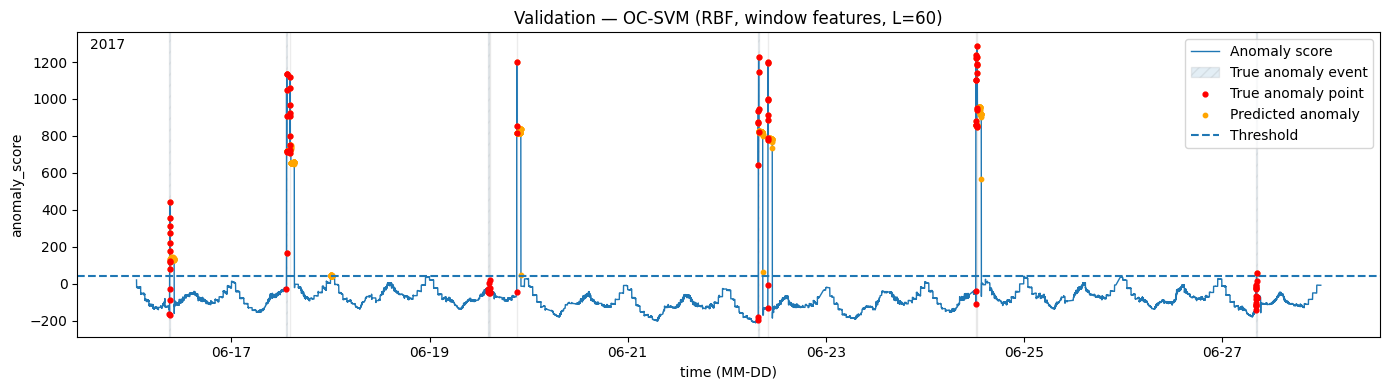

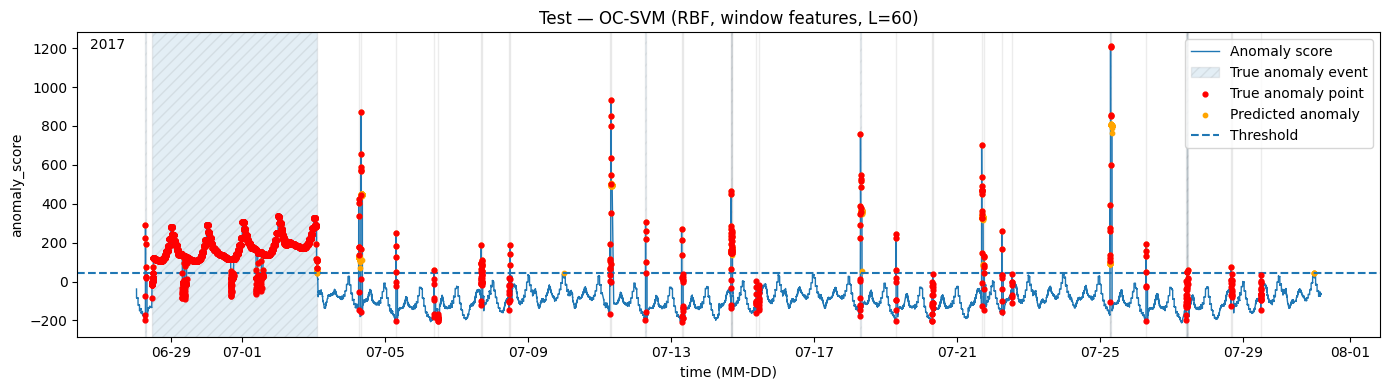

'threshold=val_event_f1'

In [214]:
# ------------------------------------------------------------
# Step 13: Tier 1 baseline — One-Class SVM on window features (L=60)
# ------------------------------------------------------------

import time
import numpy as np
import pandas as pd
from sklearn.svm import OneClassSVM

# -----------------------------
# 13.1 Resolve feature tables created in Step 11
# -----------------------------
# Expected from Step 11 (vectorised window features):
# - X_train_df, X_val_df, X_test_df (DataFrames of features)
# - meta_train_df, meta_val_df, meta_test_df (DataFrames containing "time" and "is_anomaly" at window end)
#
# If the Step 11 variables use different names, map them here once (do not rename downstream utilities).

required_X = ["X_train_df", "X_val_df", "X_test_df"]
required_meta = ["meta_train_df", "meta_val_df", "meta_test_df"]

missing = [v for v in (required_X + required_meta) if v not in globals()]
if len(missing) > 0:
    raise NameError(
        "Step 11 feature outputs are missing: "
        + ", ".join(missing)
        + ". Ensure Step 11 ran and produced X_*_df and meta_*_df."
    )

# Minimal sanity checks
for name in required_X:
    if not isinstance(globals()[name], pd.DataFrame) or globals()[name].empty:
        raise ValueError(f"{name} must be a non-empty pandas DataFrame.")

for name in required_meta:
    if not isinstance(globals()[name], pd.DataFrame) or globals()[name].empty:
        raise ValueError(f"{name} must be a non-empty pandas DataFrame.")
    if "time" not in globals()[name].columns or "is_anomaly" not in globals()[name].columns:
        raise ValueError(f"{name} must include columns: 'time', 'is_anomaly'.")

# Extract
X_train = X_train_df.copy()
X_val = X_val_df.copy()
X_test = X_test_df.copy()

meta_val = meta_val_df.copy()
meta_test = meta_test_df.copy()

# Create df_split views that match evaluation + plotting utilities
# (time + is_anomaly required; additional columns are allowed)
val_df_windows = pd.DataFrame({
    "time": meta_val["time"].astype("datetime64[ns]"),
    "is_anomaly": meta_val["is_anomaly"].astype(int),
})
test_df_windows = pd.DataFrame({
    "time": meta_test["time"].astype("datetime64[ns]"),
    "is_anomaly": meta_test["is_anomaly"].astype(int),
})

# -----------------------------
# 13.2 Experiment identifiers
# -----------------------------
MODEL_NAME = "ocsvm_rbf_window_features_L60"
TIER = 1

WINDOW_LENGTH_L = int(WINDOW_LENGTH_L)  # already defined earlier (e.g., 60)
FEATURE_MODE = "summary"               # matches Step 11 summary-style window features
USES_TIME_FEATURES = 1                 # Step 11 includes hour/day/weekend
CONTIGUITY_ENFORCED = 1                # Step 11 excluded non-contiguous windows

# OC-SVM hyperparameters (keep small + explicit)
OCSVM_KERNEL = "rbf"
OCSVM_NU = 0.05
OCSVM_GAMMA = "scale"

SCORE_DEFINITION_KEY = f"ocsvm_{OCSVM_KERNEL}_nu{OCSVM_NU}_gamma{OCSVM_GAMMA}"
SCORE_DEFINITION_TEXT = "OC-SVM anomaly score = -decision_function(window_features) (higher = more anomalous)"
THRESHOLD_STRATEGY = "val_event_f1"

# Deterministic run key + overwrite-only folder
run_key = make_run_key(
    case_study=CASE_STUDY,
    tier=TIER,
    model_name=MODEL_NAME,
    window_length_L=WINDOW_LENGTH_L,
    feature_mode=FEATURE_MODE,
    uses_time_features=USES_TIME_FEATURES,
    contiguity_enforced=CONTIGUITY_ENFORCED,
    score_definition_key=SCORE_DEFINITION_KEY,
    threshold_strategy=THRESHOLD_STRATEGY,
)
run_dir = run_dir_from_key(
    run_key=run_key,
    case_study=CASE_STUDY,
    tier=TIER,
    model_slug=MODEL_NAME,
)

# Trace id (recorded only in config)
run_id = make_run_id_timestamp()
run_timestamp = pd.Timestamp.now().isoformat()

# -----------------------------
# 13.3 Fit OC-SVM (train only) + score val/test
# -----------------------------
t0 = time.time()

ocsvm = OneClassSVM(
    kernel=OCSVM_KERNEL,
    nu=float(OCSVM_NU),
    gamma=OCSVM_GAMMA,
)

# Train
ocsvm.fit(X_train.to_numpy())
train_seconds = time.time() - t0

# Score (higher = more anomalous)
t1 = time.time()
val_scores = (-ocsvm.decision_function(X_val.to_numpy())).astype(float)
test_scores = (-ocsvm.decision_function(X_test.to_numpy())).astype(float)
score_seconds = time.time() - t1

# -----------------------------
# 13.4 Threshold search on validation (event-level)
# -----------------------------
# true_events_val / true_events_test already exist earlier (event table split views)
best_thr, thr_table = select_threshold_event_f1(
    df_split=val_df_windows,
    scores=val_scores,
    true_events_split=true_events_val,
    n_grid=60,
)

# -----------------------------
# 13.5 Evaluate at chosen threshold
# -----------------------------
val_metrics = evaluate_at_threshold(val_df_windows, val_scores, best_thr, true_events_val)
test_metrics = evaluate_at_threshold(test_df_windows, test_scores, best_thr, true_events_test)

val_metrics_df = pd.DataFrame([{"split": "validation", **val_metrics}])
test_metrics_df = pd.DataFrame([{"split": "test", **test_metrics}])

display(best_thr)
display(thr_table.head(5))
display(val_metrics_df)
display(test_metrics_df)

# -----------------------------
# 13.6 Predictions + plots (shown and saved)
# -----------------------------
val_pred_flags = (val_scores >= best_thr).astype(int)
test_pred_flags = (test_scores >= best_thr).astype(int)

fig_val = plot_score_timeline(
    df_split=val_df_windows,
    scores=val_scores,
    threshold=best_thr,
    title="Validation — OC-SVM (RBF, window features, L=60)",
    true_events_split=true_events_val,
    pred_is_anomaly=val_pred_flags,
)
plt.show()
fig_val.savefig(run_dir / "fig_val_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_val)

fig_test = plot_score_timeline(
    df_split=test_df_windows,
    scores=test_scores,
    threshold=best_thr,
    title="Test — OC-SVM (RBF, window features, L=60)",
    true_events_split=true_events_test,
    pred_is_anomaly=test_pred_flags,
)
plt.show()
fig_test.savefig(run_dir / "fig_test_timeline.png", dpi=150, bbox_inches="tight")
plt.close(fig_test)

# -----------------------------
# 13.7 Save per-run artefacts (overwrite-only folder)
# -----------------------------
config = {
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,
    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,
    "random_seed": RANDOM_SEED,

    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,

    "ocsvm_kernel": OCSVM_KERNEL,
    "ocsvm_nu": float(OCSVM_NU),
    "ocsvm_gamma": str(OCSVM_GAMMA),

    "score_definition": SCORE_DEFINITION_TEXT,
    "threshold_strategy": THRESHOLD_STRATEGY,
}
save_json(config, run_dir / "config.json")

save_json(
    {
        "threshold_strategy": THRESHOLD_STRATEGY,
        "threshold_value": float(best_thr),
        "validation_best_row": thr_table.iloc[0].to_dict(),
    },
    run_dir / "threshold.json",
)

val_pred = pd.DataFrame({
    "time": val_df_windows["time"],
    "anomaly_score": val_scores,
    "pred_is_anomaly": val_pred_flags,
    "is_anomaly": val_df_windows["is_anomaly"].astype(int),
    "split": "validation",
    "case_study": CASE_STUDY,
})
test_pred = pd.DataFrame({
    "time": test_df_windows["time"],
    "anomaly_score": test_scores,
    "pred_is_anomaly": test_pred_flags,
    "is_anomaly": test_df_windows["is_anomaly"].astype(int),
    "split": "test",
    "case_study": CASE_STUDY,
})

save_df(val_pred, run_dir / "val_predictions.csv")
save_df(test_pred, run_dir / "test_predictions.csv")
save_df(val_metrics_df, run_dir / "val_metrics.csv")
save_df(test_metrics_df, run_dir / "test_metrics.csv")
save_df(thr_table, run_dir / "val_threshold_grid.csv")


# -----------------------------
# 13.8 Log performance-only results (UPSERT by run_key)
# -----------------------------
notes = auto_notes(
    val_event_precision=float(val_metrics["event_precision"]),
    val_event_recall=float(val_metrics["event_recall"]),
    val_event_f1=float(val_metrics["event_f1"]),
    test_event_precision=float(test_metrics["event_precision"]),
    test_event_recall=float(test_metrics["event_recall"]),
    test_event_f1=float(test_metrics["event_f1"]),
    test_pr_auc=float(test_metrics["pr_auc"]),
    threshold_strategy=THRESHOLD_STRATEGY,
)

row = normalise_perf_row({
    "run_key": run_key,
    "run_id": run_id,
    "run_timestamp": run_timestamp,

    "case_study": CASE_STUDY,
    "tier": TIER,
    "model_name": MODEL_NAME,

    "window_length_L": WINDOW_LENGTH_L,
    "feature_mode": FEATURE_MODE,
    "uses_time_features": USES_TIME_FEATURES,
    "contiguity_enforced": CONTIGUITY_ENFORCED,
    "score_definition": SCORE_DEFINITION_TEXT,

    "threshold_strategy": THRESHOLD_STRATEGY,
    "threshold_value": float(best_thr),

    "val_event_precision": float(val_metrics["event_precision"]),
    "val_event_recall": float(val_metrics["event_recall"]),
    "val_event_f1": float(val_metrics["event_f1"]),
    "val_event_delay_median_minutes": float(val_metrics["event_delay_median_minutes"]),

    "test_event_precision": float(test_metrics["event_precision"]),
    "test_event_recall": float(test_metrics["event_recall"]),
    "test_event_f1": float(test_metrics["event_f1"]),
    "test_event_delay_median_minutes": float(test_metrics["event_delay_median_minutes"]),

    "test_point_precision": float(test_metrics["point_precision"]),
    "test_point_recall": float(test_metrics["point_recall"]),
    "test_point_f1": float(test_metrics["point_f1"]),
    "test_auroc": float(test_metrics["auroc"]),
    "test_pr_auc": float(test_metrics["pr_auc"]),

    "train_seconds": float(train_seconds),
    "score_seconds": float(score_seconds),

    "notes": notes,
})

upsert_all_results_row(row)
notes





## Step 13 - Interpretation: Tier 1 OC-SVM (RBF) baseline (window features, L=60) with event-level thresholding

### What was implemented
This Tier 1 baseline fits a **One-Class SVM (RBF kernel)** on **tabular window features** derived from the last **L = 60 minutes** of `value_scaled` (plus time features at the window end).  
The model produces a **continuous anomaly score** per window end timestamp. A **single threshold** is selected on **validation** by maximising **event-level F1** (`threshold=val_event_f1`), then applied unchanged to **test**.

---

### Key validation results (threshold selected on validation)
From the displayed outputs:

- **Event-level (primary)**
  - **event_precision = 0.7778**
  - **event_recall = 0.8182**
  - **event_f1 = 0.7975**
  - **event_delay_median_minutes = 2.0**

- **Point-wise (secondary diagnostics)**
  - point_precision = 0.1287
  - point_recall = 0.6289
  - point_f1 = 0.2137
  - AUROC = 0.8436
  - PR-AUC = 0.3379

**Interpretation (validation):**
- The threshold is **event-effective** (high event recall + solid precision), meaning the model tends to place at least one detection inside most true events while not over-triggering on too many non-events.
- Point-wise precision is low because the model typically flags **multiple timestamps inside an event** (and sometimes around it), which is expected when the objective is **event detection** rather than perfectly sparse point flags.
- Median detection delay of **~2 minutes** is consistent with the windowed design: detection is fast once anomalous structure enters the trailing window.

---

### Key test results (generalisation check)
Using the same validation-selected threshold:

- **Event-level (primary)**
  - **event_precision = 0.9231**
  - **event_recall = 0.7105**
  - **event_f1 = 0.8030**
  - **event_delay_median_minutes = 2.0**

- **Point-wise (secondary diagnostics)**
  - point_precision = 0.9409
  - point_recall = 0.9062
  - point_f1 = 0.9232
  - AUROC = 0.9762
  - PR-AUC = 0.8442

**Interpretation (test):**
- Event-level **precision is very high (0.923)**, indicating predicted event clusters overlap true events with minimal “phantom events”.
- Event-level recall drops relative to validation (**0.71 vs 0.82**), but overall event F1 remains strong (**~0.80**). This reflects a more conservative threshold behaviour under the test regime: fewer events are hit, but when the model fires it is usually correct.
- Point-wise metrics on test are **very strong**, and PR-AUC is high, indicating good ranking/separation of anomalous vs normal points under the test distribution.
- The timeline plot visually supports this: predicted markers cluster at true anomaly structure, especially during the dense incident regime, with limited scatter elsewhere.

---

### What the plots suggest about behaviour
- The OC-SVM score shows **sharp peaks** aligned with anomaly bands and anomaly points, which supports its suitability for **event-level detection** in the high-frequency AIOps regime.
- The combination “high test PR-AUC + high test event precision” suggests the model is not merely over-flagging; it is producing **meaningful score separation** that thresholding can exploit.

---

### Tie back to the research objectives and Case D role
- **Case D** is intended to stress methods under **high-frequency monitoring** and a **dense incident regime**. This OC-SVM baseline performs strongly in that setting, particularly on **test precision**, which is important for operational realism (avoiding excessive false incident alarms).
- The results reinforce the charter’s stance that **event-level evaluation** is the headline: OC-SVM can be strong even when point-wise behaviour may look “dense” within events (especially on validation), because the operational question is “was the incident detected?” rather than “were only a few points flagged?”

---

### Practical takeaway for Tier 1 → Tier 2 progression
- This is a **credible Tier 1 challenger baseline** for diffusion/LSTM-AE comparisons in Case D.
- The main trade-off to watch going forward is:
  - **High event precision** (good) vs **event recall sensitivity** (some misses in test).
- For future tiers, it will be important to check whether diffusion/LSTM-AE can:
  - raise **event recall** without losing precision, and/or
  - reduce delay while remaining robust to regime shifts.

---

### Notes on score scale
The OC-SVM anomaly score scale is large (hundreds to thousands), but this is not a methodological issue: it is an artefact of the model’s scoring function. Since threshold selection is performed on validation and applied consistently, comparability is maintained. Score *interpretability* is handled through thresholding + plots rather than absolute score magnitude.


# Step 14 - Baseline comparison table (Tier 0–1) and consolidated conclusion (Case D: AIOps KPI)

##  Context 

This section consolidates **Tier 0–1 baseline results** for Case D (AIOps KPI) into a single comparison view, using the performance-only `all_results.csv` registry in reporting.

Reporting follows the modelling charter rules established in earlier stages.

- **Primary objective:** external level performance (event precision, event recall, event F1, detection delay)
- **Secondary diagnostics:** validation thresholding by `val_event_f1`, AUROC, PR-AUC
- **Selection protocol:** pointwise thresholding by `val_event_f1`, then fixed-threshold evaluation on test
- **Repository:** results are retrieved from the overwrite-only run registry (no artifact pointers required)

In [217]:
# ------------------------------------------------------------
# Step 14: Baseline comparison table (Tier 0–1) — AIOps KPI
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import numpy as np

# -----------------------------
# 14.1 Load performance registry
# -----------------------------
if "ALL_RESULTS_PATH" in globals():
    all_results_path = Path(ALL_RESULTS_PATH)
else:
    all_results_path = (Path("..") / "results" / "all_results.csv")

if not all_results_path.exists():
    raise FileNotFoundError(
        f"all_results.csv not found at: {all_results_path.resolve()}. "
        "Ensure Step 6 paths are defined and results were written."
    )

all_results = pd.read_csv(all_results_path)

# -----------------------------
# 14.2 Filter: Case D (aiops_kpi), Tier 0–1 only
# -----------------------------
df = all_results.copy()
df = df[df["case_study"].astype(str).eq("aiops_kpi")]
df = df[df["tier"].astype(int).isin([0, 1])]

if df.empty:
    raise ValueError("No Tier 0–1 rows found for case_study='aiops_kpi' in all_results.csv.")

# -----------------------------
# 14.3 Select + clean comparison columns
# -----------------------------
cols = [
    # Identity / design
    "model_name", "tier",
    "window_length_L", "feature_mode", "uses_time_features", "contiguity_enforced",
    "score_definition",
    "threshold_strategy", "threshold_value",

    # Validation (threshold selection evidence)
    "val_event_precision", "val_event_recall", "val_event_f1", "val_event_delay_median_minutes",

    # Test (primary reporting)
    "test_event_precision", "test_event_recall", "test_event_f1", "test_event_delay_median_minutes",

    # Test (secondary diagnostics)
    "test_point_precision", "test_point_recall", "test_point_f1",
    "test_auroc", "test_pr_auc",

    # Notes (auto-notes tags)
    "notes",
]

cols = [c for c in cols if c in df.columns]
comparison = df[cols].copy()

# Coerce numeric columns (safe)
numeric_cols = [c for c in comparison.columns if c not in ["model_name", "feature_mode", "score_definition", "threshold_strategy", "notes"]]
for c in numeric_cols:
    comparison[c] = pd.to_numeric(comparison[c], errors="coerce")

# -----------------------------
# 14.4 Rank (primary: test event-F1)
# -----------------------------
sort_cols = [c for c in ["test_event_f1", "test_event_recall", "test_event_precision"] if c in comparison.columns]
ascending = [False] * len(sort_cols)

if "test_event_delay_median_minutes" in comparison.columns:
    sort_cols.append("test_event_delay_median_minutes")
    ascending.append(True)

comparison_ranked = comparison.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

# Optional rounding for readability
round_map = {
    "val_event_precision": 4, "val_event_recall": 4, "val_event_f1": 4, "val_event_delay_median_minutes": 2,
    "test_event_precision": 4, "test_event_recall": 4, "test_event_f1": 4, "test_event_delay_median_minutes": 2,
    "test_point_precision": 4, "test_point_recall": 4, "test_point_f1": 4,
    "test_auroc": 4, "test_pr_auc": 4,
    "threshold_value": 6,
}
for c, nd in round_map.items():
    if c in comparison_ranked.columns:
        comparison_ranked[c] = comparison_ranked[c].round(nd)

display(comparison_ranked)

# -----------------------------
# 14.5 Convenience: top overall + best per tier (for the write-up)
# -----------------------------
def pick_best(df_in: pd.DataFrame) -> pd.Series:
    return df_in.sort_values(sort_cols, ascending=ascending).iloc[0]

best_overall = pick_best(comparison_ranked)
best_tier0 = pick_best(comparison_ranked[comparison_ranked["tier"].astype(int) == 0])
best_tier1 = pick_best(comparison_ranked[comparison_ranked["tier"].astype(int) == 1])

best_summary = pd.DataFrame([
    {"group": "best_overall", **best_overall.to_dict()},
    {"group": "best_tier0", **best_tier0.to_dict()},
    {"group": "best_tier1", **best_tier1.to_dict()},
])

display(best_summary[["group", "model_name", "tier", "test_event_f1", "test_event_recall", "test_event_precision", "test_event_delay_median_minutes", "test_pr_auc", "test_auroc"]])


,model_name,tier,window_length_L,feature_mode,uses_time_features,contiguity_enforced,score_definition,threshold_strategy,threshold_value,val_event_precision,val_event_recall,val_event_f1,val_event_delay_median_minutes,test_event_precision,test_event_recall,test_event_f1,test_event_delay_median_minutes,test_point_precision,test_point_recall,test_point_f1,test_auroc,test_pr_auc,notes
0,ocsvm_rbf_window_features_L60,1,60,summary,1,1,OC-SVM anomaly score = -decision_function(wind...,val_event_f1,4.307562e+01,0.7778,0.8182,0.7975,2.0,0.9231,0.7105,0.8030,2.0,0.9409,0.9062,0.9232,0.9762,0.8442,threshold=val_event_f1
1,isolation_forest_window_features,1,60,summary,1,1,IsolationForest score = -decision_function(win...,val_event_f1,1.318870e-01,0.9000,1.0000,0.9474,2.0,0.6761,0.9737,0.7980,3.0,0.3901,0.0717,0.1211,0.9524,0.6210,threshold=val_event_f1
2,heuristic_moving_z_60min_abs_value_scaled,0,0,none,0,1,abs((value_scaled - moving_mean_60min) / movin...,val_event_f1,7.015874e+00,0.4375,0.6364,0.5185,1.0,1.0000,0.3684,0.5385,1.0,1.0000,0.0049,0.0097,0.1133,0.1359,threshold=val_event_f1
3,heuristic_moving_median_mad_60min_abs_value_sc...,0,0,none,0,1,abs((value_scaled - moving_median_60min) / max...,val_event_f1,4.971024e+06,1.0000,0.2727,0.4286,1.0,1.0000,0.1053,0.1905,4.5,1.0000,0.0037,0.0074,0.2193,0.1558,conservative_threshold_val;threshold=val_event_f1
4,heuristic_static_z_abs_value_scaled,0,0,none,0,1,abs(value_scaled) at each timestamp,val_event_f1,1.236076e+01,1.0000,0.6364,0.7778,3.0,1.0000,0.0263,0.0513,3.0,1.0000,0.0003,0.0006,0.9907,0.9865,conservative_threshold_test;conservative_thres...
5,heuristic_moving_median_mad_floor_60min_abs_va...,0,0,none,0,1,abs((value_scaled - moving_median_60min) / max...,val_event_f1,5.366125e+01,1.0000,0.3636,0.5333,2.0,1.0000,0.0263,0.0513,4.0,1.0000,0.0001,0.0003,0.2179,0.1849,conservative_threshold_test;conservative_thres...


,group,model_name,tier,test_event_f1,test_event_recall,test_event_precision,test_event_delay_median_minutes,test_pr_auc,test_auroc
0,best_overall,ocsvm_rbf_window_features_L60,1,0.8030,0.7105,0.9231,2.0,0.8442,0.9762
1,best_tier0,heuristic_moving_z_60min_abs_value_scaled,0,0.5385,0.3684,1.0000,1.0,0.1359,0.1133
2,best_tier1,ocsvm_rbf_window_features_L60,1,0.8030,0.7105,0.9231,2.0,0.8442,0.9762


## Step 14 - Conclusion and baseline comparison: Tier 0–1 results for Case D (AIOps KPI)

### What was completed in this notebook
Tier 0–1 baselines were implemented for the AIOps KPI case study using:

- **Primary objective:** **event-level thresholding + event-level metrics** (precision/recall/F1; median detection delay).
- **Secondary diagnostics:** point-wise precision/recall/F1, **AUROC**, **PR-AUC**.
- A consistent run registry design (run_key overwrite-only runs; **performance-only `all_results.csv`**).

The completed models in `all_results.csv` are:

**Tier 1 (window features, L=60, summary + time features)**
- `ocsvm_rbf_window_features_L60`
- `isolation_forest_window_features`

**Tier 0 (time-series score baselines; no window feature table)**
- `heuristic_static_z_abs_value_scaled`
- `heuristic_moving_z_60min_abs_value_scaled`
- `heuristic_moving_median_mad_60min_abs_value_scaled`
- `heuristic_moving_median_mad_floor_60min_abs_value_scaled`

All models used **validation-selected thresholding via `val_event_f1`**.

---

### Headline comparison on test (event-level primary)

**Best overall / best Tier 1**
- **OC-SVM (RBF, window features, L=60):**
  - **test_event_f1 = 0.8030**
  - test_event_recall = 0.7105
  - test_event_precision = 0.9231
  - test_event_delay_median_minutes = 2.0
  - test_pr_auc = 0.8442
  - test_auroc = 0.9762

**Tier 1 runner-up**
- **Isolation Forest (window features, L=60):**
  - **test_event_f1 = 0.7980**
  - test_event_recall = 0.9737
  - test_event_precision = 0.6761
  - test_event_delay_median_minutes = 3.0
  - test_pr_auc = 0.6210
  - test_auroc = 0.9524

**Best Tier 0**
- **Moving z-score (60min):**
  - **test_event_f1 = 0.5385**
  - test_event_recall = 0.3684
  - test_event_precision = 1.0000
  - test_event_delay_median_minutes = 1.0
  - test_pr_auc = 0.1359
  - test_auroc = 0.1133

**Tier 0 robust variants (not competitive on test event detection)**
- Moving median + MAD (60min): **test_event_f1 = 0.1905**, test_event_recall = 0.1053, test_event_precision = 1.0000, delay = 4.5, PR-AUC = 0.1558, AUROC = 0.2193
- Static z-score: **test_event_f1 = 0.0513**, test_event_recall = 0.0263, test_event_precision = 1.0000, delay = 3.0, PR-AUC = 0.9865, AUROC = 0.9907
- Moving median + MAD with floor: **test_event_f1 = 0.0513**, test_event_recall = 0.0263, test_event_precision = 1.0000, delay = 4.0, PR-AUC = 0.1849, AUROC = 0.2179

---

### Interpretation of the key pattern: event-level vs point-wise diagnostics diverge sharply
A central empirical result in Case D is that **some baselines can look “excellent” under point-wise ranking metrics while failing under event-level detection**, which is the primary objective for this research.

- The **static z-score baseline** shows **very high AUROC/PR-AUC** on test (AUROC ≈ 0.9907; PR-AUC ≈ 0.9865) while having **very low event recall** (0.0263) and **very low event F1** (0.0513).
- This combination is consistent with a setting where:
  - the continuous score strongly separates many normal vs anomalous *points* in aggregate, **but**
  - the **chosen event-level threshold (selected on validation)** becomes **overly conservative on test**, producing very few predicted anomaly points and therefore missing most events.

This validates the decision in the Modelling & Evaluation Charter to treat **event-level detection as primary**, because point-wise ranking metrics alone can be misleading in an operational AIOps setting where the unit of interest is an **incident/event** rather than isolated points.

---

### Why Tier 1 window-feature baselines dominate in this case study
Both Tier 1 methods (IF and OC-SVM) substantially outperform all Tier 0 heuristics on the primary objective (test event F1 near **0.80** vs Tier 0 best at **0.54**). This supports the methodological claim that Case D benefits from **contextual window representation** rather than only instantaneous magnitude/robust deviations.

**What the window features likely capture (based on the feature set used):**
- local distributional context (mean/std/min/max),
- recent endpoint behaviour (`w_last`),
- local trend (`w_slope`),
- time-of-day/week structure (hour/day/weekend).

Given AIOps KPI dynamics often include regime-like patterns, bursts, and structured seasonality, these features provide the model with **a more expressive view of “normal” behaviour**, making event detection more reliable.

---

### OC-SVM vs Isolation Forest: trade-off observed on test
Both Tier 1 models are strong, but they express different operational trade-offs:

- **OC-SVM (best overall)** prioritises **high event precision** (0.9231) while keeping event recall reasonably high (0.7105).  
  This yields the best event F1 (0.8030) and strong PR-AUC/AUROC, suggesting a comparatively **cleaner alarm set** while still detecting most events.

- **Isolation Forest** pushes event recall extremely high (0.9737) but at the cost of lower event precision (0.6761).  
  This is consistent with a **more trigger-happy detector**: it catches almost all events but introduces more false event alarms, which lowers event precision and PR-AUC.

In an incident-management setting, these differences matter:
- If the operational cost of missing events is dominant, IF-like behaviour can be attractive.
- If alert fatigue and false alarms are costly, OC-SVM-like behaviour can be preferable.

---

### Tier 0 results: what they still contribute (despite weaker event performance)
Tier 0 baselines are not competitive against Tier 1 on event-level detection for Case D, but they remain useful as:

1. **Sanity checks / transparency anchors**  
   They provide interpretable scoring rules and can confirm that the pipeline detects extreme deviations when thresholds are permissive.

2. **Evidence of threshold-transfer sensitivity**  
   The strong validation results for some Tier 0 methods do not transfer to test event detection (e.g., static z-score).  
   This is an empirical reminder that **validation-to-test threshold stability is non-trivial** in Case D and motivates drift-aware modelling/evaluation later in the project.

3. **Motivation for moving from point magnitude to context**  
   The gap between Tier 0 and Tier 1 supports the research intuition that “single-point deviation” is insufficient in AIOps KPI data and that **contextual behaviour** is essential.

---

### Tie back to the research objectives and Case D’s role
Case D (AIOps KPI) was selected as the “dense incident / operational regime” case study. The results align with the broader dissertation framing in two ways:

- **Objective alignment (event-first evaluation):**  
  The observed divergence between point-wise metrics and event-level success reinforces that event-level evaluation is the correct primary objective for operational anomaly detection.

- **Efficiency vs effectiveness baseline yardstick:**  
  Tier 1 baselines provide a strong, efficient benchmark (~0.80 test event F1) that any Tier 2–3 method (LSTM AE, diffusion-based) must convincingly exceed or match while offering additional benefits (robustness, calibration stability, drift handling, or improved precision/recall trade-offs).

---

### Practical takeaway for Tier 1 → Tier 2 progression (LSTM AE and diffusion)
The baseline layer establishes a clear reference point:

- **Baseline to beat:** OC-SVM (RBF, window features, L=60) with **test_event_f1 = 0.8030** and high precision.
- **Strong alternate operating point:** Isolation Forest with very high recall.

For Tier 2 (LSTM AE) and Tier 3 (diffusion), the next phase should focus on demonstrating at least one of:

- improved event F1 beyond ~0.80,
- better balance of event precision/recall (e.g., maintain recall while improving precision, or maintain precision while improving recall),
- improved **threshold stability / calibration transfer** from validation to test,
- robustness under regime shifts or concept drift (consistent with the dissertation framing).

Given the strong performance already achieved with window-feature models, Tier 2–3 models should be designed and reported with particular attention to:
- the same event-level thresholding discipline,
- comparable window length(s) (starting with L=60 as the anchored reference),
- explicit discussion of any compute/complexity trade-offs relative to Tier 1.

---

### Final baseline verdict for Case D
- **Tier 1 dominates Tier 0** on event-level detection for AIOps KPI.
- **OC-SVM is the best overall baseline** in this run (event F1 0.8030; high precision 0.9231).
- **Isolation Forest is nearly tied** in event F1 (0.7980) but behaves as a higher-recall, lower-precision detector.
- **Tier 0 heuristics provide interpretability and diagnostic value** but do not achieve competitive event-level performance on test in this case study.
